# Introduction
## Statement of Purpose
The purpose of this analysis is to apply the full Exploratory Data Analysis (EDA) workflow to a real-world dataset of airline performance metrics. Our goal is to apply this workflow in order to answer meaningful question driven inquiries on U.S. airline performance metrics. Our aim is to develop a deep understanding of operational patterns, reliability factors, and delay drivers across, airlines, airports, and time periods.

## Source Data
* **United States Department of Transportation - U.S. Buerau of Transportation Statistics (Airlines, Airport, and Aviation)**
    
    URL: https://transtats.bts.gov/Fields.asp?gnoyr_VQ=FGJ

* **Federal Aviation Administration Aircraft Registration Database**
    
    URL: https://www.faa.gov/licenses_certificates/aircraft_certification/aircraft_registry/releasable_aircraft_download

# Step 0: Initial Questions To Answer

**1. What do we want to know about airline on-time performance?**
* **How does on-time performance vary across carrier, airports, time, day, maybe aircraft?**
  
    - What's the overall distribution of any flight delays? 
    -  What airline has the best and worst on-time performance? 
    -  How do routes (short/long) correlate with performance? 
    -  What departure time windows have the least amount of delays? Most amount of delays? 
    -  What is the average delay per airport? per airline? per airport & airline? 
    - What percentage of flights leave on-time? Delayed? 
    -  What time ranges have the highest/lowest delays? 
        - How many flights per day? 
        - By airport? By carrier? 
    - What is the average aircraft turnaround time by carrier? (I'd think we'd have to subtract any weather, security, or NAS delays because those are not impacted their ability to get the aircraft ready for the next flight) 

* **What delay propagation patterns can we draw?**
  - Is there recovery or do they compound / propagate? 
    - Are some airlines better at recovering than others? 
  - What information can we draw from taxi times? Thinking about traffic jams at the runways due to built up delays
  - What percent of flights are delayed 15, 30, 60+ minutes? 
  - What is the % chance that a late arrival will cause the next flight to also be late 
  - What is the average total time per day in delays a carrier has? 
  - What correlations are there between delays and cancelations (mainly downstream, think about how a major storm could cause mass cancellations in a short period of time)? 

* **What factors have the greatest effect on on-time performance**
  - Weather 
    - What is the average number of delays per day due to weather?
    - What percentage of days are due to weather?
    - Which airports have the highest/most frequent weather delays?
    - How much time is the average weather delay?
  - Secuirty 
    - What percentage of delays are due to security issues?
    - How much time is the average security delay? 
  - Carrier 
    - Which carriers have the highest delays?
    - How much time is the average carrier delay
  - National Aviation System (Delay within control of ATC, not airline) 
    - Which airports have the most/highest delays due to NAS?
    - How much time is the average NAS delau
    - What is the total number 

* **What is the impact to customers?**
  - Which airports should customers expect delays
  - What percent of flights are delayed 15, 30, 60+ minutes?

* **Ambitious Questions**
  - What is the overall cost of delays?**
    - Fuel, labor, etc.

2. How will the answers be useful in decision making?

# Key Features Needed
  1. Date
  2. Time of Day
  3. Carrier
  4. Airport (Departure)
  5. Airport (Arrival) / Destination
  6. Flight Delay Code
  7. Tail Number
  8. Elapsed Time
  9. State
  10. Wheels Up
  11. Wheel Down
  12. Taxi Time 




# 1. Initial Load & Reconniassance 
## Questions to Answer
1. Tidy or not?
2. Entities, Attributes, Observations?
3. Variable Types?
4. Shape & scale?
5. Any obvious problems?

### Hypothessis
- Relationships worth exploring
    - Numeric
    - Categorical
    - Numeric vs Categorical
    - Numeric vs Numeric 
    -  on-time performance vs. time of day
    -  on-time performance vs carrier
    -  on-time performance vs airport
    -  Carrier vs % of flights delayed
    -  Carrier vs departure / arrival delays


## Importing Libraries

In [4]:
import pandas as pd
import numpy as np
from pathlib import Path
import zipfile
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

## Reading In All The Source Data

In [5]:
df = pd.read_parquet("../data/bts_all.parquet") #initital load of parquet file containing main DF data from Beaurue of Transportation Stats
df_aircraft = pd.read_csv("../data/Aircraft.csv") #csv file of aircraft tail numbers and their makes and models
df_airports = pd.read_csv("../data/Airports.csv") #csv file of airport codes and their country
df_airline = pd.read_csv("../data/Airline.csv") #csv file of airline codes and they're full names

## Data Preview

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4688354 entries, 0 to 4688353
Data columns (total 33 columns):
 #   Column              Dtype  
---  ------              -----  
 0   FlightDate          object 
 1   Reporting_Airline   object 
 2   Tail_Number         object 
 3   Origin              object 
 4   OriginCityName      object 
 5   OriginStateName     object 
 6   Dest                object 
 7   DestCityName        object 
 8   DestStateName       object 
 9   CRSDepTime          int64  
 10  DepTime             float64
 11  DepDelay            float64
 12  TaxiOut             float64
 13  WheelsOff           float64
 14  WheelsOn            float64
 15  TaxiIn              float64
 16  CRSArrTime          int64  
 17  ArrTime             float64
 18  ArrDelay            float64
 19  Cancelled           float64
 20  CancellationCode    object 
 21  Diverted            float64
 22  ActualElapsedTime   float64
 23  AirTime             float64
 24  Distance            floa

* Expected:
  - FlightDate to be datetime
  - CRSDepTime & CRSArrTime to be datetime
  - DepTime & ArrTime to be datatime
  - WheelsOff & WheelsOn to be datetime

* Fixes:
  - Update all expected datetime objects to their appropriate datetime 

## Data Distribution

In [7]:
df.describe()

,CRSDepTime,DepTime,DepDelay,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrTime,ArrDelay,...,AirTime,Distance,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,TotalAddGTime,DivAirportLandings,DivReachedDest
count,4.688354e+06,4.408518e+06,4.408455e+06,4.407823e+06,4.407823e+06,4.406514e+06,4.406514e+06,4.688354e+06,4.406515e+06,4.399575e+06,...,4.399575e+06,4.688354e+06,431920.000000,431920.000000,431920.000000,431920.000000,431920.000000,24131.00000,4.688267e+06,7744.000000
mean,1.314967e+03,1.312348e+03,2.059625e+00,1.522011e+01,1.336366e+03,1.475165e+03,6.814271e+00,1.496015e+03,1.482458e+03,-4.989810e+00,...,1.090486e+02,7.802486e+02,26.070138,4.385740,13.501266,0.146053,18.198713,29.67262,2.629970e-03,0.896178
std,4.631090e+02,4.684129e+02,3.616458e+01,8.193911e+00,4.682740e+02,4.827119e+02,5.036725e+00,4.811746e+02,4.847662e+02,3.820511e+01,...,6.664947e+01,5.560499e+02,75.645611,34.238937,30.989914,3.514856,49.879709,23.22630,1.018481e-01,0.305050
min,1.000000e+00,1.000000e+00,-1.280000e+02,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-1.390000e+02,...,7.000000e+00,2.900000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,0.000000e+00,0.000000
25%,9.250000e+02,9.240000e+02,-7.000000e+00,1.000000e+01,9.380000e+02,1.110000e+03,4.000000e+00,1.123000e+03,1.115000e+03,-1.900000e+01,...,6.000000e+01,3.700000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,15.00000,0.000000e+00,1.000000
50%,1.310000e+03,1.312000e+03,-4.000000e+00,1.300000e+01,1.325000e+03,1.506000e+03,5.000000e+00,1.518000e+03,1.511000e+03,-1.100000e+01,...,9.300000e+01,6.390000e+02,0.000000,0.000000,1.000000,0.000000,0.000000,24.00000,0.000000e+00,1.000000
75%,1.710000e+03,1.712000e+03,-1.000000e+00,1.800000e+01,1.725000e+03,1.851000e+03,8.000000e+00,1.904000e+03,1.857000e+03,-1.000000e+00,...,1.390000e+02,1.015000e+03,25.000000,0.000000,18.000000,0.000000,17.000000,37.00000,0.000000e+00,1.000000
max,2.359000e+03,2.400000e+03,3.890000e+03,1.890000e+02,2.400000e+03,2.400000e+03,2.800000e+02,2.400000e+03,2.400000e+03,3.864000e+03,...,6.980000e+02,5.095000e+03,3864.000000,1706.000000,1462.000000,1185.000000,2361.000000,291.00000,9.000000e+00,1.000000


## DataFrame Shape

In [8]:
df.shape

(4688354, 33)

## DataFrame Preview

### Each row represents one scheduled flight on a specific FlightDate

In [9]:
df.head()

,FlightDate,Reporting_Airline,Tail_Number,Origin,OriginCityName,OriginStateName,Dest,DestCityName,DestStateName,CRSDepTime,...,AirTime,Distance,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,TotalAddGTime,DivAirportLandings,DivReachedDest
0,2020-09-01,OH,N506AE,PHL,"Philadelphia, PA",Pennsylvania,DAY,"Dayton, OH",Ohio,1905,...,76.0,477.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
1,2020-09-02,OH,N512AE,PHL,"Philadelphia, PA",Pennsylvania,DAY,"Dayton, OH",Ohio,1905,...,68.0,477.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
2,2020-09-03,OH,N710PS,PHL,"Philadelphia, PA",Pennsylvania,DAY,"Dayton, OH",Ohio,1905,...,77.0,477.0,0.0,0.0,26.0,0.0,0.0,NaN,0.0,NaN
3,2020-09-04,OH,N712PS,PHL,"Philadelphia, PA",Pennsylvania,DAY,"Dayton, OH",Ohio,1905,...,73.0,477.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
4,2020-09-05,OH,N705PS,PHL,"Philadelphia, PA",Pennsylvania,DAY,"Dayton, OH",Ohio,1905,...,72.0,477.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN


## Column Attributes

In [10]:
df.columns.tolist()

['FlightDate',
 'Reporting_Airline',
 'Tail_Number',
 'Origin',
 'OriginCityName',
 'OriginStateName',
 'Dest',
 'DestCityName',
 'DestStateName',
 'CRSDepTime',
 'DepTime',
 'DepDelay',
 'TaxiOut',
 'WheelsOff',
 'WheelsOn',
 'TaxiIn',
 'CRSArrTime',
 'ArrTime',
 'ArrDelay',
 'Cancelled',
 'CancellationCode',
 'Diverted',
 'ActualElapsedTime',
 'AirTime',
 'Distance',
 'CarrierDelay',
 'WeatherDelay',
 'NASDelay',
 'SecurityDelay',
 'LateAircraftDelay',
 'TotalAddGTime',
 'DivAirportLandings',
 'DivReachedDest']

## Missing Data

In [11]:
df.columns[df.isna().any()].tolist()

['Tail_Number',
 'DepTime',
 'DepDelay',
 'TaxiOut',
 'WheelsOff',
 'WheelsOn',
 'TaxiIn',
 'ArrTime',
 'ArrDelay',
 'CancellationCode',
 'ActualElapsedTime',
 'AirTime',
 'CarrierDelay',
 'WeatherDelay',
 'NASDelay',
 'SecurityDelay',
 'LateAircraftDelay',
 'TotalAddGTime',
 'DivAirportLandings',
 'DivReachedDest']

#### For the attributes with missing data, we will explore in section 2 

# 2. Data Quality

- What is broken, missing, or suspicious?
- Are the dtypes correct for each variable?
- Do the values make sense?
- Where is data missing and how much?
- Are there duplicates or outliers?
- Is the data trustworthy as is?

In [12]:
#Displaying dataframe of missing values for each feature and their percent relative to the entire DataFrame
att_missing = df.isna().sum().sort_values(ascending=False)
pct_missing = df.isna().mean().sort_values(ascending=False)
missing = pd.DataFrame({
      'missing_count': att_missing,
      'percent_missing': (pct_missing*100).round(1)
})
missing

,missing_count,percent_missing
DivReachedDest,4680610,99.8
TotalAddGTime,4664223,99.5
CancellationCode,4407320,94.0
LateAircraftDelay,4256434,90.8
SecurityDelay,4256434,90.8
CarrierDelay,4256434,90.8
NASDelay,4256434,90.8
WeatherDelay,4256434,90.8
AirTime,288779,6.2
ActualElapsedTime,288779,6.2


* Missing Data:
  - Tail Numbers
    - Not super critical to fix since this would really only be used to track delays by aircraft. If we don't plan to do that, then we can just drop the column entirely. We COULD, however, clean the data frame up a little bit to show only the flights associated with large carrier airlines and remove private flights
  - Departure Time
    - Similar to Tail Numbers, we could remove private flights to see how this changes. We'll have to assess if removing a percentage of the data for each 
  - Departure Delay
  - Taxi Out
  - Wheels Off
  - Wheels On
  - Taxi In
  - Arrival Time
  - Arrival Delay
  - Cancellation Code
  - Elapsed Time
  - Air Time
  - Carrier Delay
  - Weather Delay
  - NASDelay
  - Security Delay
  - LateAircraftDelay
  - Total Additional Ground Time
    - This attribute will be droped from the dataset
  - Diverted Airport Landing
    - This attribute will be dropped from the dataset
  - Diverted Aircraft Reached Destination 
    - This attribute will be dropped fro the dataset

* Notes:
  - To avoid creating bias in the data, the missing rows for DepDelay and ArrDelay columns will be dropped
  


# 3. Cleaning Decisions

- Motivation
    - How do I fix problems without corrupting the truth?
- Questions
    - Drop or fix? What's the impact on the analysis?
    - What the missingness mechanism (MCAR / MAR / MNAR)
    - Are outliers legit or are they errors?
    - What assumptions am I making?
- Hypothesis & Iteration
    - What biases might my cleaning decisions introduce
    - What sensitivity analyses should I run?
- Iteration Signals
    - Cleaning reveals new issues --> back to phase 2
    - Decisions feel arbitrary --> need domain expertise  

For the cleaning decisions section the goal is to correct structural issues within the dataframe while avoiding unintended transformations that may distort the true data. We will drop rows, and coluns with missing data or data that is not applicable to our analyses. All the decisions made will ideally reflect best knoweldge of the airline operations domain

## Converting To Proper Dtypes & Time Fields

In [13]:
#Converting FlightDate to datetime object
df['FlightDate'] = pd.to_datetime(df['FlightDate'], errors="coerce") #Displaying only date for Flight Date

# Turn departure time into a datetime object for better analysis
# This require combining the time information with flight date

# Prep a series of strings to comibe with flight dates
crs_str = (
    df["CRSDepTime"]
    .astype(str)
    .str.zfill(4)     # "0730", "1745"
)

# Combine FL_DATE + hh:mm into a true datetime
df["CRSDepDateTime"] = pd.to_datetime(
    df["FlightDate"].dt.strftime("%Y-%m-%d") + " " +
    crs_str.str.slice(0, 2) + ":" + crs_str.str.slice(2, 4),
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)
df

# df = df["CRSDepDateTime"].unique()
# df

#df['FlightDate'] = pd.to_datetime(df['FlightDate'], errors="coerce") #Displaying only date for Flight Date
# #df['FlightDate'] = df['FlightDate'].dt.strftime("%d/%m/%Y") #Formatting date to be in dd/mm/yyyy format

# df['CRSDepTime'] = df['CRSDepTime'].astype(str).str.zfill(4) #Converting int64 to 4 digit string
# df['CRSArrTime'] = df['CRSArrTime'].astype(str).str.zfill(4) #Converting int64 to 4 digit string
# df['CRSDepTime'] = pd.to_datetime(df['CRSDepTime'], format="%H%M", errors='coerce') #Converting string to datetime with format proper hours and minutes format. Any invalid values will become NaT
# df['CRSArrTime'] = pd.to_datetime(df['CRSArrTime'], format="%H%M", errors='coerce') #Converting string to datetime with format proper hours and minutes format. Any invalid values will become NaT
# df.info()
# #df

,FlightDate,Reporting_Airline,Tail_Number,Origin,OriginCityName,OriginStateName,Dest,DestCityName,DestStateName,CRSDepTime,...,Distance,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,TotalAddGTime,DivAirportLandings,DivReachedDest,CRSDepDateTime
0,2020-09-01,OH,N506AE,PHL,"Philadelphia, PA",Pennsylvania,DAY,"Dayton, OH",Ohio,1905,...,477.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,2020-09-01 19:05:00
1,2020-09-02,OH,N512AE,PHL,"Philadelphia, PA",Pennsylvania,DAY,"Dayton, OH",Ohio,1905,...,477.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,2020-09-02 19:05:00
2,2020-09-03,OH,N710PS,PHL,"Philadelphia, PA",Pennsylvania,DAY,"Dayton, OH",Ohio,1905,...,477.0,0.0,0.0,26.0,0.0,0.0,NaN,0.0,NaN,2020-09-03 19:05:00
3,2020-09-04,OH,N712PS,PHL,"Philadelphia, PA",Pennsylvania,DAY,"Dayton, OH",Ohio,1905,...,477.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,2020-09-04 19:05:00
4,2020-09-05,OH,N705PS,PHL,"Philadelphia, PA",Pennsylvania,DAY,"Dayton, OH",Ohio,1905,...,477.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,2020-09-05 19:05:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4688349,2020-04-01,YX,N648RW,CLT,"Charlotte, NC",North Carolina,DEN,"Denver, CO",Colorado,1645,...,1337.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,2020-04-01 16:45:00
4688350,2020-04-01,YX,N645RW,CLE,"Cleveland, OH",Ohio,EWR,"Newark, NJ",New Jersey,1700,...,404.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,2020-04-01 17:00:00
4688351,2020-04-01,YX,N725YX,BUF,"Buffalo, NY",New York,EWR,"Newark, NJ",New Jersey,700,...,282.0,132.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,2020-04-01 07:00:00
4688352,2020-04-01,YX,N730YX,HRL,"Harlingen/San Benito, TX",Texas,IAH,"Houston, TX",Texas,730,...,295.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,2020-04-01 07:30:00


## Checking to make sure dates of last and first flights are within the proper date range for which data was collected

In [14]:
#Checking that earliest date of dataset to be January 1, 2020
earliest_flight = df['FlightDate'].min()
latest_flight = df['FlightDate'].max()
print("Earliest Flight Date:", earliest_flight.date())
print("Latest Flight Date:", latest_flight.date())

Earliest Flight Date: 2020-01-01
Latest Flight Date: 2020-12-31


## Stripping integers/letters from values within Tail Number column

In [15]:
#Removing leading "N" from Tail Number 
df['Tail_Number'] = df['Tail_Number'].str.lstrip('N') 

## Merging With Aircraft DataFrame

In [16]:
#Dropping column, "MFR MDL CODE" within Aircraft DataFrame
df_aircraft = df_aircraft.drop(columns='MFR MDL CODE') 

#Changing feature names for Aircraft DataFrame
df_aircraft = df_aircraft.rename(columns= { 
    'N-NUMBER': 'Tail_Number',
    'MFR': 'Manufacturer',
    'NO-SEATS': 'Number_of_Seats'
})

#Merging main DataFrame with Aircraft DataFrame
df = df.merge(df_aircraft, on='Tail_Number', how='left') 

## Merging With Airport DataFrame

In [17]:
#Merging with Airport.csv
dep_airports = df_airports.copy()
dep_airports = dep_airports.rename(columns={'lid': 'DepAirport_code',
                                          'country': 'dep_country'})
df = df.merge(dep_airports[['DepAirport_code', 'dep_country']], left_on='Origin', right_on='DepAirport_code', how='left')

dest_airports = df_airports.copy()
dest_airports = dest_airports.rename(columns={'lid': 'DestAirport_code',
                                          'country': 'dest_country'})
df = df.merge(dest_airports[['DestAirport_code', 'dest_country']], left_on='Dest', right_on='DestAirport_code', how='left')

# mask = (df['dep_country'] != 'US') | (df['dest_country'] != 'US')
# df.loc[mask, 'international'] = 'International'
# df.loc[~mask, 'international'] = 'Domestic'
# df = df.drop(columns=['DepAirport_code', 'dep_country', 'DestAirport_code', 'dest_country'])

## Merging with Airline DataFrame

In [18]:
#Merging with Airline.csv
df_airline = df_airline.rename(columns= {'OP_UNIQUE_CARRIER': 'Reporting_Airline'})

df = df.merge(df_airline, on='Reporting_Airline', how='left')

# air_unique = df['Airline'].unique().tolist() #Show number of unique airlines in the main DF
# air_counts = df['Airline'].value_counts(dropna=False) #Count # of occurrences for each unique airline, including rows with NaN values. We will drop rows with NaN later
# #air_show = df[df['Airline'].isna()].head(5) #Show first 5 rows of observations with NaN for airline
# # df = df[df['DepDelay'].isna()].head(5)
# df.head()


## Additional DataFrame Column Renaming

In [19]:
mask = (df['dep_country'] != 'US') | (df['dest_country'] != 'US')
df.loc[mask, 'international'] = 'International'
df.loc[~mask, 'international'] = 'Domestic'
df = df.drop(columns=['DepAirport_code', 'dep_country', 'DestAirport_code', 'dest_country'])

#Renaming some column names
df = df.rename(columns= { 'international': 'flight_type',
                          'Description': 'Airline'})

#Renaming the airlines for simplicity and readability
df['Airline'] = df['Airline'].replace({
    'American Airlines Inc.': 'American Airlines',
    'Alaska Airlines Inc.': 'Alaska Airlines',
    'Delta Air Lines Inc.': 'Delta Airlines',
    'Frontier Airlines Inc.': 'Frontier Airlines',
    'Hawaiian Airlines Inc.': 'Hawaiian Airlines',
    'PSA Airlines Inc.': 'PSA Airlines',
    'Skywest Airlines Inc.': 'Skywest Airlines',
    'United Air Lines Inc.': 'United Airlines',
    'Southwest Airlines Co.': 'Southwest Airlines',
})   
df

,FlightDate,Reporting_Airline,Tail_Number,Origin,OriginCityName,OriginStateName,Dest,DestCityName,DestStateName,CRSDepTime,...,LateAircraftDelay,TotalAddGTime,DivAirportLandings,DivReachedDest,CRSDepDateTime,Manufacturer,MODEL,Number_of_Seats,Airline,flight_type
0,2020-09-01,OH,506AE,PHL,"Philadelphia, PA",Pennsylvania,DAY,"Dayton, OH",Ohio,1905,...,NaN,NaN,0.0,NaN,2020-09-01 19:05:00,BOMBARDIER INC,CL-600-2C10,80.0,PSA Airlines,Domestic
1,2020-09-02,OH,512AE,PHL,"Philadelphia, PA",Pennsylvania,DAY,"Dayton, OH",Ohio,1905,...,NaN,NaN,0.0,NaN,2020-09-02 19:05:00,BOMBARDIER INC,CL-600-2C10,80.0,PSA Airlines,Domestic
2,2020-09-03,OH,710PS,PHL,"Philadelphia, PA",Pennsylvania,DAY,"Dayton, OH",Ohio,1905,...,0.0,NaN,0.0,NaN,2020-09-03 19:05:00,BOMBARDIER INC,CL-600-2C10,80.0,PSA Airlines,Domestic
3,2020-09-04,OH,712PS,PHL,"Philadelphia, PA",Pennsylvania,DAY,"Dayton, OH",Ohio,1905,...,NaN,NaN,0.0,NaN,2020-09-04 19:05:00,BOMBARDIER INC,CL-600-2C10,80.0,PSA Airlines,Domestic
4,2020-09-05,OH,705PS,PHL,"Philadelphia, PA",Pennsylvania,DAY,"Dayton, OH",Ohio,1905,...,NaN,NaN,0.0,NaN,2020-09-05 19:05:00,BOMBARDIER INC,CL-600-2C10,80.0,PSA Airlines,Domestic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4688349,2020-04-01,YX,648RW,CLT,"Charlotte, NC",North Carolina,DEN,"Denver, CO",Colorado,1645,...,NaN,NaN,0.0,NaN,2020-04-01 16:45:00,EMBRAER,ERJ 170-100 SE,70.0,Republic Airline,Domestic
4688350,2020-04-01,YX,645RW,CLE,"Cleveland, OH",Ohio,EWR,"Newark, NJ",New Jersey,1700,...,NaN,NaN,0.0,NaN,2020-04-01 17:00:00,NaN,NaN,NaN,Republic Airline,Domestic
4688351,2020-04-01,YX,725YX,BUF,"Buffalo, NY",New York,EWR,"Newark, NJ",New Jersey,700,...,0.0,NaN,0.0,NaN,2020-04-01 07:00:00,EMBRAER S A,ERJ 170-200 LR,88.0,Republic Airline,Domestic
4688352,2020-04-01,YX,730YX,HRL,"Harlingen/San Benito, TX",Texas,IAH,"Houston, TX",Texas,730,...,NaN,NaN,0.0,NaN,2020-04-01 07:30:00,EMBRAER S A,ERJ 170-200 LR,88.0,Republic Airline,Domestic


# Address Missing Data

In [20]:
#Displaying dataframe of missing values for each feature and their percent relative to the entire DataFrame
att_missing = df.isna().sum().sort_values(ascending=False)
pct_missing = df.isna().mean().sort_values(ascending=False)
missing = pd.DataFrame({
      'missing_count': att_missing,
      'percent_missing': (pct_missing*100).round(1)
})
missing

# Drop any rows where we still failed to build a datetime
df = df[df["CRSDepDateTime"].notna()].copy()

#Dropping 'Reporting_Airline' column since a new column with airline info was created
df = df.drop(columns=['Reporting_Airline'])

#Drop rows with no company airline. These are likely private carriers we want to exclude. Only looking to capture major airlines
df = df.dropna(subset=['Airline']) 

#Dropping unnecessary columns from DataFrame
df = df.drop(columns= ['TotalAddGTime', 'DivAirportLandings', 'DivReachedDest'])

# Drop any rows from the DataFrame where we still failed to build a datetime
df = df[df["CRSDepDateTime"].notna()].copy()

#Drop rows with NaN in the DepTime column
df = df.dropna(subset=['DepTime']) 

#Drop rows with NaN in the ArrTime column
df = df.dropna(subset=['ArrTime'])

#Drop rows with NaN in the DepDelay column
df = df.dropna(subset=['DepDelay'])

#Drop rows with NaN in the ArrDelay column
df = df.dropna(subset=['ArrDelay'])

df = df.drop(columns= ['Number_of_Seats'])
df


,FlightDate,Tail_Number,Origin,OriginCityName,OriginStateName,Dest,DestCityName,DestStateName,CRSDepTime,DepTime,...,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,CRSDepDateTime,Manufacturer,MODEL,Airline,flight_type
0,2020-09-01,506AE,PHL,"Philadelphia, PA",Pennsylvania,DAY,"Dayton, OH",Ohio,1905,1858.0,...,NaN,NaN,NaN,NaN,NaN,2020-09-01 19:05:00,BOMBARDIER INC,CL-600-2C10,PSA Airlines,Domestic
1,2020-09-02,512AE,PHL,"Philadelphia, PA",Pennsylvania,DAY,"Dayton, OH",Ohio,1905,1858.0,...,NaN,NaN,NaN,NaN,NaN,2020-09-02 19:05:00,BOMBARDIER INC,CL-600-2C10,PSA Airlines,Domestic
2,2020-09-03,710PS,PHL,"Philadelphia, PA",Pennsylvania,DAY,"Dayton, OH",Ohio,1905,1855.0,...,0.0,0.0,26.0,0.0,0.0,2020-09-03 19:05:00,BOMBARDIER INC,CL-600-2C10,PSA Airlines,Domestic
3,2020-09-04,712PS,PHL,"Philadelphia, PA",Pennsylvania,DAY,"Dayton, OH",Ohio,1905,1857.0,...,NaN,NaN,NaN,NaN,NaN,2020-09-04 19:05:00,BOMBARDIER INC,CL-600-2C10,PSA Airlines,Domestic
4,2020-09-05,705PS,PHL,"Philadelphia, PA",Pennsylvania,DAY,"Dayton, OH",Ohio,1905,1856.0,...,NaN,NaN,NaN,NaN,NaN,2020-09-05 19:05:00,BOMBARDIER INC,CL-600-2C10,PSA Airlines,Domestic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4688348,2020-04-01,653RW,CMH,"Columbus, OH",Ohio,IAD,"Washington, DC",Virginia,615,610.0,...,NaN,NaN,NaN,NaN,NaN,2020-04-01 06:15:00,EMBRAER,ERJ 170-100 SE,Republic Airline,Domestic
4688350,2020-04-01,645RW,CLE,"Cleveland, OH",Ohio,EWR,"Newark, NJ",New Jersey,1700,1652.0,...,NaN,NaN,NaN,NaN,NaN,2020-04-01 17:00:00,NaN,NaN,Republic Airline,Domestic
4688351,2020-04-01,725YX,BUF,"Buffalo, NY",New York,EWR,"Newark, NJ",New Jersey,700,933.0,...,132.0,0.0,0.0,0.0,0.0,2020-04-01 07:00:00,EMBRAER S A,ERJ 170-200 LR,Republic Airline,Domestic
4688352,2020-04-01,730YX,HRL,"Harlingen/San Benito, TX",Texas,IAH,"Houston, TX",Texas,730,720.0,...,NaN,NaN,NaN,NaN,NaN,2020-04-01 07:30:00,EMBRAER S A,ERJ 170-200 LR,Republic Airline,Domestic


## Summary Statistics

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
df.shape

In [ ]:
df.columns

# What percent of reported delays were NOT given a specific delay code?

## Number of International & Domestic Flights

In [8]:
#Displaying number of domestic flights vs. international
inter = df['flight_type'].value_counts()
inter

flight_type
Domestic         4257799
International      30824
Name: count, dtype: int64

Things to note:
1. Some departure and/or arrival delays are noted but are not given is a designation as a reaosn to why
2. All rows for each delay category are listed as NaN is there was no report of a dealy specifically cause by one of the categories
3. Some flight records do not have a tail number recorded. This could make tracking based on routes skewed as well as show no make or model for that aircraft
    - For our purposes, for filtering by aircraft, we will only consider records that have aircraft make and model listed
 


# 4. Statistical EDA

- Motivation
  - What patterns, relationships stories exist in the data?
- Driving Questions
  - What's "typical" for each variable?
  - How do variables relate to each other?
  - Do patterns hold across subgroups?
  - What surprises emerge?

In this Exploratory Data Analysis (EDA) is to explore and quantify key patterns, relationships, and operational behaviors within the Beaueru of Transportation Statistics On-TIme Performance dataset. In this phase, we will seek to move beyond structuure and quaity checking and begin to analyze how flight delays vary across airlines, airports, and time periods. By applying the techniques learned in class, our aim is to identify tendencies, distributions, correlations, and group level difference that reveal how and why delays occur. In addition we hope to provide some general stats that give individual reviews a sense of scale or magnitude at which the airline industry operates at. 

## How do routes correlate with delays?
We're looking to assess how delays vary by route. In this context, we'll define a route as a departure/arrival airport pair.  We are interested in identifying the routes with the highest average delay per flight. 

In [100]:
#create a route column from origin and destination columns
df.copy()
df["route"] = df["Origin"] + "_" + df["Dest"]

#build a dataframe of flight delay information for each route
route_delay = (
    df.groupby("route")
      .agg(total_arr_delay=("ArrDelay", "sum"),
           n_flights=("ArrDelay", "count"))
      .sort_values("n_flights", ascending=False)
)

In [101]:
route_delay['avg_delay_per_flight'] = route_delay['total_arr_delay'] / route_delay['n_flights']
route_delay.head()

,total_arr_delay,n_flights,avg_delay_per_flight
route,,,
SFO_LAX,-115906.0,8020,-14.452120
LAX_SFO,-94561.0,8007,-11.809791
LAX_LAS,-43031.0,6691,-6.431176
LAS_LAX,-62372.0,6654,-9.373610
PHX_DEN,-35583.0,6068,-5.864041


#### Establish a minimum number of flights
To avoid the results being skewed by routes with very few flights, we'll establish a minimum threshold of number of flights in order for a route to be considered in the analysis. To do this, we'll start with a cutoff that includes 80% of all flights and adjust as necessary.

In [102]:
# Compute the cumulative percentage of total flights as routes are sorted by descending flight count
route_delay["cumulative_share"] = route_delay["n_flights"].cumsum() / route_delay["n_flights"].sum()
route_delay

,total_arr_delay,n_flights,avg_delay_per_flight,cumulative_share
route,,,,
SFO_LAX,-115906.0,8020,-14.452120,0.001995
LAX_SFO,-94561.0,8007,-11.809791,0.003987
LAX_LAS,-43031.0,6691,-6.431176,0.005652
LAS_LAX,-62372.0,6654,-9.373610,0.007307
PHX_DEN,-35583.0,6068,-5.864041,0.008817
...,...,...,...,...
MSY_SJC,-5.0,1,-5.000000,0.999999
CGI_PAH,-17.0,1,-17.000000,0.999999
PNS_MCI,-19.0,1,-19.000000,1.000000


In [103]:
#Establish 80% cutoff mark
cutoff_row = route_delay[route_delay["cumulative_share"] >= 0.80].iloc[0]
cutoff_value = cutoff_row["n_flights"]
cutoff_value


np.float64(613.0)

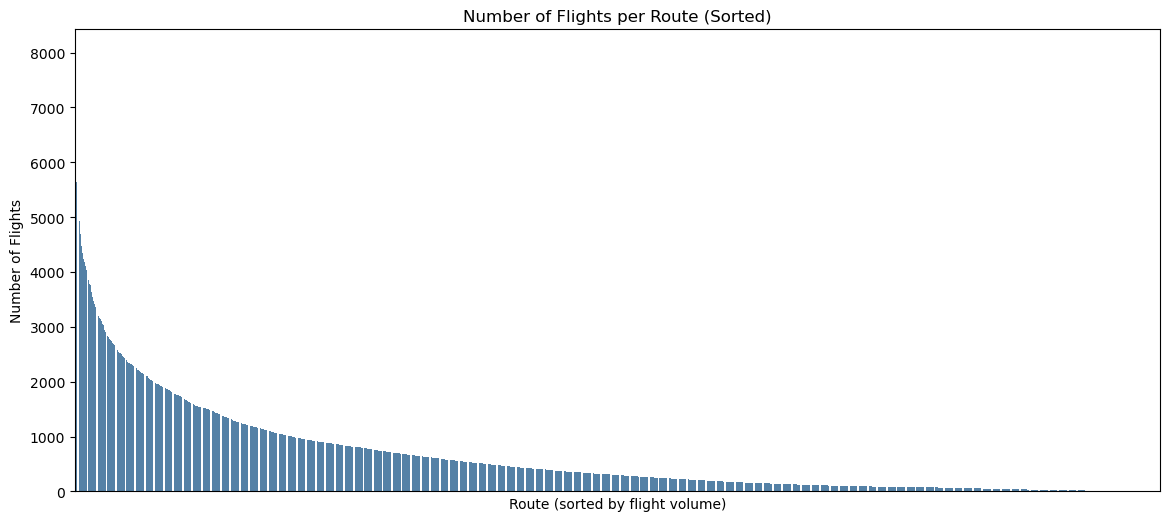

In [104]:
plt.figure(figsize=(14,6))
sns.barplot(
    data=route_delay.sort_values("n_flights", ascending=False),
    x=route_delay.sort_values("n_flights", ascending=False).index,
    y="n_flights",
    color="steelblue"
)
plt.title("Number of Flights per Route (Sorted)")
plt.xlabel("Route (sorted by flight volume)")
plt.ylabel("Number of Flights")
plt.xticks([], [])   #hide x-axis labels
plt.show()

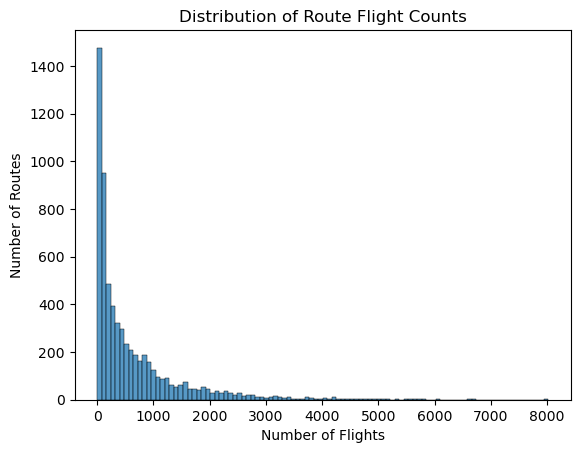

In [105]:
sns.histplot(route_delay["n_flights"], bins=100)
plt.title("Distribution of Route Flight Counts")
plt.xlabel("Number of Flights")
plt.ylabel("Number of Routes")
plt.show()


Given the above histogram and bar char, there is a long tail of lower-volume routes that might be of interest.  Let's up the threshold to 95% of flights.

In [106]:
#Establish 95% cutoff mark
cutoff_row = route_delay[route_delay["cumulative_share"] >= 0.95].iloc[0]
cutoff_value = cutoff_row["n_flights"]
cutoff_value

np.float64(197.0)

A minimum threshold of 1623 flights for a route covers 95% of all flights. Now, we'll find the average delay time per flight for all routes with 1623 flights or more.

In [107]:
min_flights = 1623


filtered_routes = route_delay[route_delay["n_flights"] >= min_flights]

# Sort by highest avg delay per flight
filtered_routes = filtered_routes.sort_values(
    "avg_delay_per_flight",
    ascending=False
)
filtered_routes.drop(columns=["cumulative_share"], inplace=True) # cumulative share doesn't make sense in this context



In [108]:
worst_routes = filtered_routes.head()
worst_routes

,total_arr_delay,n_flights,avg_delay_per_flight
route,,,
LIT_DFW,12968.0,1877,6.908897
IAH_DFW,17516.0,2582,6.783888
AUS_DFW,16758.0,2515,6.663221
MEM_DFW,9488.0,1637,5.795968
OKC_DFW,8740.0,1676,5.214797


In [109]:
best_routes = filtered_routes.tail()
best_routes

,total_arr_delay,n_flights,avg_delay_per_flight
route,,,
BOS_SFO,-32361.0,2058,-15.724490
PHL_ORD,-49561.0,3048,-16.260171
LGA_CLT,-42151.0,2577,-16.356616
DCA_ORD,-52775.0,3198,-16.502502
JFK_SFO,-60005.0,3198,-18.763290


Based on this analysis, there is no standout commonality among the best and worst routes for delays or early arrivals.  Let's explore volume per day at the airports in the top 5 and bottom 5 in the delay data to see if there is a signal there.

In [110]:
top_worst_airports = ["BDL", "SJU", "DCA", "ASE", "DFW", "MDT", "EYW", "PHL"]
top_best_airports  = ["BTM", "SLC", "KOA", "OAK", "RHI", "MSP", "TYS", "DTW", "LIH", "DEN"]

airport_daily_volume = (
    df.melt(
        id_vars=["FlightDate"],
        value_vars=["Origin", "Dest"],
        var_name="type",
        value_name="airport"
    )
    .groupby(["airport", "FlightDate"])
    .size()
    .reset_index(name="flights_per_day")
)


In [111]:
# Average volume / day at the airports in the worst routes
worst_filtered = (
    airport_daily_volume[airport_daily_volume["airport"].isin(top_worst_airports)]
)
worst_filtered_avg = worst_filtered.groupby("airport")["flights_per_day"].mean()

In [112]:
# Average volume / day at the airports in the best routes
best_filtered = (
    airport_daily_volume[airport_daily_volume["airport"].isin(top_best_airports)]
)
best_filtered_avg = best_filtered.groupby("airport")["flights_per_day"].mean()

In [113]:
def create_route_volume_df(route_df,filtered_avg):
    """
    Given a dataframe of routes and a series of averages,
    create a dataframe of routes with volume totals and differences
    """
    rows = []
    for route in route_df.index:
        origin,dest = route.split("_")
        volume_diff = filtered_avg[origin] - filtered_avg[dest]
        total_volume = filtered_avg[origin] + filtered_avg[dest]
        rows.append({
            "route": route,
            "origin": origin,
            "dest": dest,
            "volume_diff": volume_diff,
            "total_volume": total_volume
        })
    
    return pd.DataFrame(rows).set_index("route")


    
    

In [114]:
best_route_volumes_df = create_route_volume_df(best_routes,best_filtered_avg)
best_route_volumes_df

KeyError: 'BOS'

In [115]:
worst_route_volumes_df = create_route_volume_df(worst_routes,worst_filtered_avg)
worst_route_volumes_df

KeyError: 'LIT'

# What is the distributions of departure delays?

In [21]:
df = df.copy()
df
#df['DepDelay'].plot(kind='hist', bins=10, figsize=(10,4))


,FlightDate,Tail_Number,Origin,OriginCityName,OriginStateName,Dest,DestCityName,DestStateName,CRSDepTime,DepTime,...,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,CRSDepDateTime,Manufacturer,MODEL,Airline,flight_type
0,2020-09-01,506AE,PHL,"Philadelphia, PA",Pennsylvania,DAY,"Dayton, OH",Ohio,1905,1858.0,...,NaN,NaN,NaN,NaN,NaN,2020-09-01 19:05:00,BOMBARDIER INC,CL-600-2C10,PSA Airlines,Domestic
1,2020-09-02,512AE,PHL,"Philadelphia, PA",Pennsylvania,DAY,"Dayton, OH",Ohio,1905,1858.0,...,NaN,NaN,NaN,NaN,NaN,2020-09-02 19:05:00,BOMBARDIER INC,CL-600-2C10,PSA Airlines,Domestic
2,2020-09-03,710PS,PHL,"Philadelphia, PA",Pennsylvania,DAY,"Dayton, OH",Ohio,1905,1855.0,...,0.0,0.0,26.0,0.0,0.0,2020-09-03 19:05:00,BOMBARDIER INC,CL-600-2C10,PSA Airlines,Domestic
3,2020-09-04,712PS,PHL,"Philadelphia, PA",Pennsylvania,DAY,"Dayton, OH",Ohio,1905,1857.0,...,NaN,NaN,NaN,NaN,NaN,2020-09-04 19:05:00,BOMBARDIER INC,CL-600-2C10,PSA Airlines,Domestic
4,2020-09-05,705PS,PHL,"Philadelphia, PA",Pennsylvania,DAY,"Dayton, OH",Ohio,1905,1856.0,...,NaN,NaN,NaN,NaN,NaN,2020-09-05 19:05:00,BOMBARDIER INC,CL-600-2C10,PSA Airlines,Domestic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4688348,2020-04-01,653RW,CMH,"Columbus, OH",Ohio,IAD,"Washington, DC",Virginia,615,610.0,...,NaN,NaN,NaN,NaN,NaN,2020-04-01 06:15:00,EMBRAER,ERJ 170-100 SE,Republic Airline,Domestic
4688350,2020-04-01,645RW,CLE,"Cleveland, OH",Ohio,EWR,"Newark, NJ",New Jersey,1700,1652.0,...,NaN,NaN,NaN,NaN,NaN,2020-04-01 17:00:00,NaN,NaN,Republic Airline,Domestic
4688351,2020-04-01,725YX,BUF,"Buffalo, NY",New York,EWR,"Newark, NJ",New Jersey,700,933.0,...,132.0,0.0,0.0,0.0,0.0,2020-04-01 07:00:00,EMBRAER S A,ERJ 170-200 LR,Republic Airline,Domestic
4688352,2020-04-01,730YX,HRL,"Harlingen/San Benito, TX",Texas,IAH,"Houston, TX",Texas,730,720.0,...,NaN,NaN,NaN,NaN,NaN,2020-04-01 07:30:00,EMBRAER S A,ERJ 170-200 LR,Republic Airline,Domestic


# What percent of flights leave on time/delayed?

In [22]:
#Make copy of main dataframe & drop rows with NaN in the DepTime column
df = df.copy()

#Counting total number of applicable flights
dep_count = len(df) 

#Calculating percent of flights that are late
dep_late = (df['DepDelay'] > 0).mean()

#Calculating percent of flights that are on-time
on_time = (df['DepDelay'] == 0).mean() 

#Calculating percent of flights that are early
dep_early = (df['DepDelay'] < 0).mean() 

#Printing results
print(f"Percent of Departures That Are Late: {dep_late:.1%}")
print(f"\nPercent of Departures That Are On-Time: {on_time:.1%}")
print(f"\nPercent of Departures That Are Early: {dep_early:.1%}")


Percent of Departures That Are Late: 19.6%

Percent of Departures That Are On-Time: 4.2%

Percent of Departures That Are Early: 76.1%


# INCOMPLETE: How does this vary month by month or year by year?

In [23]:
#Make copy of main dataframe & check dtypes
df = df.copy()
df,info()

NameError: name 'info' is not defined

FlightDate dtype is already a datetime object

In [ ]:
#Add column 'Year'
df['Year'] = df['FlightDate'].dt.year

#Counting total number of applicable flights
dep_count = len(df) 

#Calculating percent of flights that are late
dep_late = (df['DepDelay'] > 0).mean()

#Calculating percent of flights that are on-time
on_time = (df['DepDelay'] == 0).mean() 

#Calculating percent of flights that are early
dep_early = (df['DepDelay'] < 0).mean() 

#Printing results
print(f"Percent of Departures That Are Late: {dep_late:.1%}")
print(f"\nPercent of Departures That Are On-Time: {on_time:.1%}")
print(f"\nPercent of Departures That Are Early: {dep_early:.1%}")

## What is the % chance that a late arrival will cause the next flight to also be late?

Check and make sure dytpes are correct

In [24]:
df = df.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4019711 entries, 0 to 4688353
Data columns (total 34 columns):
 #   Column             Dtype         
---  ------             -----         
 0   FlightDate         datetime64[ns]
 1   Tail_Number        object        
 2   Origin             object        
 3   OriginCityName     object        
 4   OriginStateName    object        
 5   Dest               object        
 6   DestCityName       object        
 7   DestStateName      object        
 8   CRSDepTime         int64         
 9   DepTime            float64       
 10  DepDelay           float64       
 11  TaxiOut            float64       
 12  WheelsOff          float64       
 13  WheelsOn           float64       
 14  TaxiIn             float64       
 15  CRSArrTime         int64         
 16  ArrTime            float64       
 17  ArrDelay           float64       
 18  Cancelled          float64       
 19  CancellationCode   object        
 20  Diverted           float64   

In [ ]:

df = df.sort_values(['Tail_Number', 'FlightDate', 'DepTime'])
df['next_delay'] = df.groupby('Tail_Number')['DepDelay'].shift(-1)
df['late_arr'] = df['ArrDelay'] > 0
df['next_dep_delay'] = df['next_delay'] > 0
late_arr = df[df['late_arr'] == True]
probability = late_arr['next_dep_delay'].mean()
print(f"\nLikelyhood a late arrival causes next flight to be late: {probability: .2%}")


Likelyhood a late arrival causes next flight to be late:  19.25%


# INCOMPLETE: What percent of flights are delayed 15, 30, 60 minutes?

In [ ]:
df = df.copy()
df = 

60016    1.0
68631    1.0
30112    1.0
84125    1.0
7962     1.0
        ... 
74204    0.0
75028    0.0
52301    0.0
25065    0.0
66862    0.0
Name: 15_mins, Length: 100000, dtype: float64

In [47]:
df = df['15_mins'].astype(float)
df['15_mins'] = df['DepDelay'] <= 15
fifteen_mins = df['15_mins'].sum()
fifteen_mins
# df['30_mins'] = df['DepDelay'] <= 30
# df['60_mins'] = df['DepDelay'] <= 60

# delay_mins = df.groupby([15])

KeyError: 'DepDelay'

## What is the likelyhood of a delay by airline?

In [25]:
#Counting the number of flights for each airline
airline_flights = df_delay.groupby('Airline').size().reset_index(name='No. of Flights').sort_values('No. of Flights', ascending=False)

#Cleaning DF to only show specified column features as well as only show rows that have departure or arrival delays greater than 0
df_clean = df[['FlightDate', 'DepDelay', 'ArrDelay', 'Airline']]
df_delays = df_clean[(df_clean['DepDelay'] > 0) | (df_clean['ArrDelay'] > 0)]

#Grouping by Airline, showing the number of delays for departure and arrivals respectively
airline_dep_delay = (df_delays[df_delays['DepDelay']>0].groupby('Airline').size().reset_index(name='Departure_Delays'))
airline_arr_delay = (df_delays[df_delays['ArrDelay']>0].groupby('Airline').size().reset_index(name='Arrival_Delays'))
delays = airline_dep_delay.merge(airline_arr_delay, on='Airline', how='outer')
delays['Total_Delays'] = delays['Departure_Delays'] + delays['Arrival_Delays']

#Percent chance a flight is delayed by airline for either a departure or an arrival
delays['chance_of_dep_delay'] = ((delays['Departure_Delays'] / airline_flights['No. of Flights'])*100).round(1)
delays['chance_of_arr_delay'] = ((delays['Arrival_Delays'] / airline_flights['No. of Flights'])*100).round(1)
delays

NameError: name 'df_delay' is not defined

In [ ]:
airline_delay = df.groupby('Airline')

### How does this vary by airline?

### How does this vary by airport?

# What airports have the highest/worst delays?

We will measure this in two ways:

    1. Departure Delays
    2. Arrival Delays
    3. Total Delays 

Note: Some delays are recorded but are not designated as carrier, weather, NAS, or late aircraft related

In [79]:
#Airports with worst departure and arrival delays
airports_origin = df['Origin'].unique().tolist()
airports_dest = df['Dest'].unique().tolist()
worst_dep = df.groupby('Origin')['DepDelay'].sum().sort_values(ascending=False).reset_index()
worst_arr = df.groupby('Dest')['ArrDelay'].sum().sort_values(ascending=False).reset_index()

/var/folders/hz/d2mv2jxn6fl85mfk3ln_rxz80000gn/T/ipykernel_7022/1004946984.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/hz/d2mv2jxn6fl85mfk3ln_rxz80000gn/T/ipykernel_7022/1004946984.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


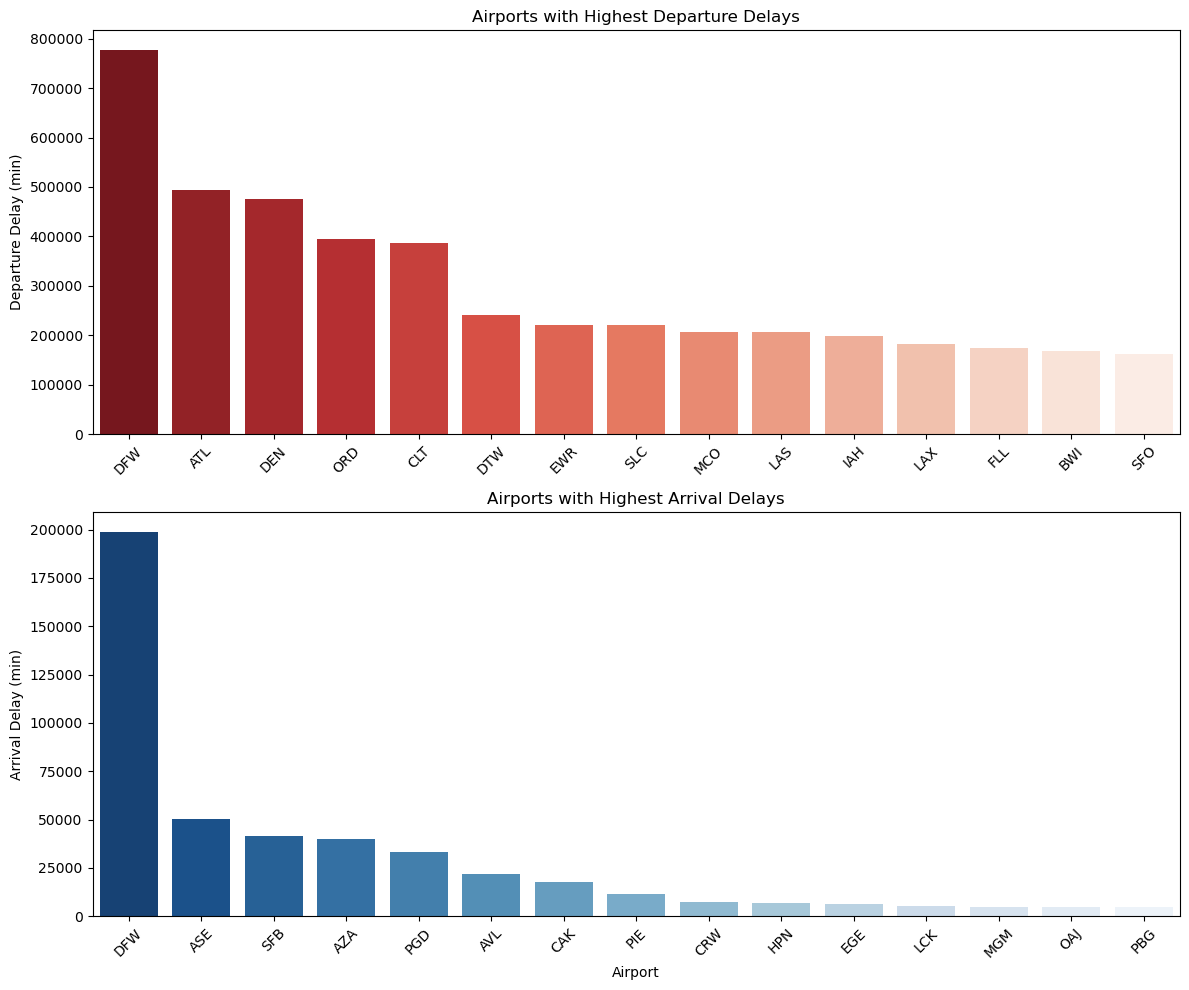

In [ ]:
# fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# # --- Plot 1: Departure delays ---
# sns.barplot(
#     data=worst_dep.head(15),
#     x='Origin', 
#     y='DepDelay',
#     palette='Reds_r',
#     ax=axes[0]
# )
# axes[0].set_title("Airports with Highest Departure Delays")
# axes[0].set_xlabel("")
# axes[0].set_ylabel("Departure Delay (min)")
# axes[0].tick_params(axis='x', rotation=45)

# # --- Plot 2: Arrival delays ---
# sns.barplot(
#     data=worst_arr.head(15),
#     x='Dest', 
#     y='ArrDelay',
#     palette='Blues_r',
#     ax=axes[1]
# )
# axes[1].set_title("Airports with Highest Arrival Delays")
# axes[1].set_xlabel("Airport")
# axes[1].set_ylabel("Arrival Delay (min)")
# axes[1].tick_params(axis='x', rotation=45)

# plt.tight_layout()
# plt.show()

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# --- Plot 1: Departure Delays ---
sns.barplot(
    data=worst_dep.head(15),
    x='Origin',
    y='DepDelay',
    palette='Reds_r',
    ax=axes[0]
)
axes[0].set_title("Airports with Highest Total Departure Delays")
axes[0].set_xlabel("Origin Airport")
axes[0].set_ylabel("Total Departure Delay (min)")
axes[0].tick_params(axis='x', rotation=45)

# --- Plot 2: Arrival Delays ---
sns.barplot(
    data=worst_arr.head(15),
    x='Dest',
    y='ArrDelay',
    palette='Blues_r',
    ax=axes[1]
)
axes[1].set_title("Airports with Highest Total Arrival Delays")
axes[1].set_xlabel("Destination Airport")
axes[1].set_ylabel("Total Arrival Delay (min)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

What if we investigated by month or year for each

In [36]:
df = df.copy()
df['Year'] = df['FlightDate'].dt.year #extracting year
df['Month'] = df['FlightDate'].dt.month #extracting month

#Departures
worst_dep_yr = df.groupby(['Year', 'Origin']).agg( #groupby year and origin airport to aggegrate sum, mean and median of depdelays per year and sort them in ascending order by total delays
    total_dep_delays=('DepDelay', 'sum'),
    avg_dep_delay=('DepDelay', 'mean'),
    median_dep_delay=('DepDelay', 'median')
).sort_values(['Year', 'total_dep_delays'], ascending=[True,False]).groupby('Year').head(5)

worst_dep_mo = df.groupby(['Month', 'Origin']).agg( #groupby month and origin airport to aggegrate sum, mean and median of depdelays per month and sort them in ascending order by total delays
    total_dep_delays=('DepDelay', 'sum'),
    avg_dep_delay=('DepDelay', 'mean'),
    median_dep_delay=('DepDelay', 'median')
).sort_values(['Month', 'total_dep_delays'], ascending=[True,False]).groupby('Month').head(5)

#Arrivals
worst_dest_yr = df.groupby(['Year', 'Dest']).agg( #groupby year and origin airport to aggegrate sum, mean and median of depdelays per year and sort them in ascending order by total delays
    total_arr_delays=('ArrDelay', 'sum'),
    avg_arr_delay=('ArrDelay', 'mean'),
    median_arr_delay=('ArrDelay', 'median')
).sort_values(['Year', 'total_arr_delays'], ascending=[True,False]).groupby('Year').head(5)

worst_dest_mo = df.groupby(['Month', 'Dest']).agg( #groupby month and origin airport to aggegrate sum, mean and median of depdelays per month and sort them in ascending order by total delays
    total_arr_delays=('ArrDelay', 'sum'),
    avg_arr_delay=('ArrDelay', 'mean'),
    median_arr_delay=('ArrDelay', 'median')
).sort_values(['Month', 'total_arr_delays'], ascending=[True,False]).groupby('Month').head(5)

worst_dest_mo

total_arr_delays  avg_arr_delay  median_arr_delay
Month Dest                                                   
1     DFW           106539.0       5.134905              -6.0
      CLT            21467.0       1.106546              -7.0
      ASE            19474.0      22.644186              -6.0
      EWR            19172.0       1.929161              -8.0
      SEA            15137.0       1.320855              -5.0
2     CLT           168686.0       9.545383              -6.0
      DFW            66462.0       3.355480              -7.0
      ATL            58931.0       2.247902              -9.0
      ORD            44238.0       1.977913             -12.0
      EWR            33499.0       3.507749              -9.0
3     LAS            70604.0       6.779720              -7.0
      DFW            16672.0       0.896007              -9.0
      AZA             5232.0       8.239370               0.0
      CAK             2520.0       6.810811              -7.0
      HOB             2104.0      30.941176              -6.0
4     AZA             4578.0      38.470588              -7.0
      PGD             3127.0      20.305195              -9.0
      ROC             2908.0      10.810409             -17.0
      SFB             1651.0      36.688889             -15.0
      PIE              887.0       9.855556             -22.5
5     SFB             6752.0      17.402062              -7.0
      AZA             2988.0      10.787004              -7.0
      PGD             2562.0       8.211538              -6.0
      LCK             1293.0      18.211268              -8.0
      OGS              992.0      30.060606             -13.0
6     PGD             3798.0      10.292683              -6.0
      AZA             2008.0       5.270341              -5.0
      LCK             1718.0      14.559322              -6.0
      SJU             1439.0       1.550647              -4.0
      ABE              863.0       4.741758              -6.0
7     DFW            37422.0       2.194839              -5.0
      SLC             6228.0       0.855612              -4.0
      ORF             3975.0       4.215270              -7.0
      SFB             2689.0       3.182249             -11.0
      AZA             2316.0       5.158129              -9.0
8     DFW             7258.0       0.415979              -5.0
      MLU             2854.0      39.638889              -7.0
      ANC             2416.0       1.900865              -3.0
      PGD             2358.0       6.478022              -9.5
      CID             1850.0       4.332553             -10.0
9     DFW            48208.0       3.112603              -5.0
      EUG             2956.0       9.566343              -8.0
      PGD             1416.0       6.077253              -5.0
      LWS             1305.0      20.076923               5.0
      GRK             1249.0       8.271523              -2.0
10    DFW           102778.0       5.883451              -3.0
      PGD             6306.0      15.014286              -1.0
      SFB             6273.0      10.317434              -6.0
      AVL             4520.0      14.037267              -4.0
      AZA             3559.0       8.473810              -3.0
11    AVL             2535.0       7.705167              -6.0
      AZA             1837.0       4.292056              -6.0
      FLG             1180.0       7.919463              -5.0
      ANC             1124.0       1.328605              -5.0
      SFB             1025.0       1.650564              -9.0
12    DFW            56735.0       3.279290              -5.0
      DTW            19212.0       2.767901              -6.0
      MSP            13599.0       2.157886              -8.0
      ASE            13292.0      24.167273              -2.0
      JFK            11463.0       3.425882              -6.0

Now we plot 

/var/folders/hz/d2mv2jxn6fl85mfk3ln_rxz80000gn/T/ipykernel_5243/1844904535.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/hz/d2mv2jxn6fl85mfk3ln_rxz80000gn/T/ipykernel_5243/1844904535.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


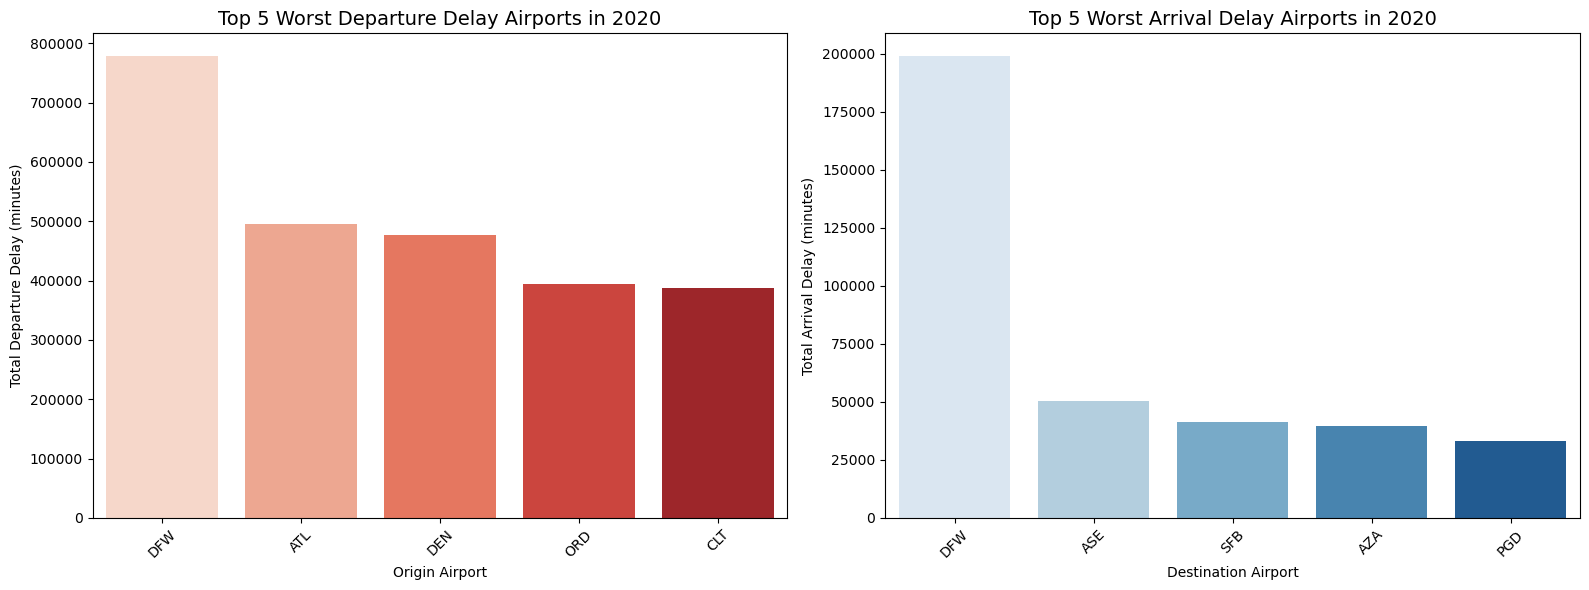

In [38]:
# Reset index to make columns available
plot_dep = worst_dep_yr.reset_index()
plot_arr = worst_dest_yr.reset_index()

years = sorted(plot_dep['Year'].unique())

for yr in years:
    # Filter data for the given year
    dep_data = plot_dep[plot_dep['Year'] == yr]
    arr_data = plot_arr[plot_arr['Year'] == yr]

    # Create figure with 2 side-by-side subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # ----- LEFT: Departure Delays -----
    sns.barplot(
        data=dep_data,
        x='Origin',
        y='total_dep_delays',
        ax=axes[0],
        palette='Reds'
    )
    axes[0].set_title(f"Top 5 Worst Departure Delay Airports in {yr}", fontsize=14)
    axes[0].set_xlabel("Origin Airport")
    axes[0].set_ylabel("Total Departure Delay (minutes)")
    axes[0].tick_params(axis='x', rotation=45)

    # ----- RIGHT: Arrival Delays -----
    sns.barplot(
        data=arr_data,
        x='Dest',
        y='total_arr_delays',
        ax=axes[1],
        palette='Blues'
    )
    axes[1].set_title(f"Top 5 Worst Arrival Delay Airports in {yr}", fontsize=14)
    axes[1].set_xlabel("Destination Airport")
    axes[1].set_ylabel("Total Arrival Delay (minutes)")
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

/var/folders/hz/d2mv2jxn6fl85mfk3ln_rxz80000gn/T/ipykernel_5243/1358999881.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/hz/d2mv2jxn6fl85mfk3ln_rxz80000gn/T/ipykernel_5243/1358999881.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/hz/d2mv2jxn6fl85mfk3ln_rxz80000gn/T/ipykernel_5243/1358999881.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/hz/d2mv2jxn6fl85mfk3ln_rxz80000gn/T/ipykernel_5243/1358999881.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and w

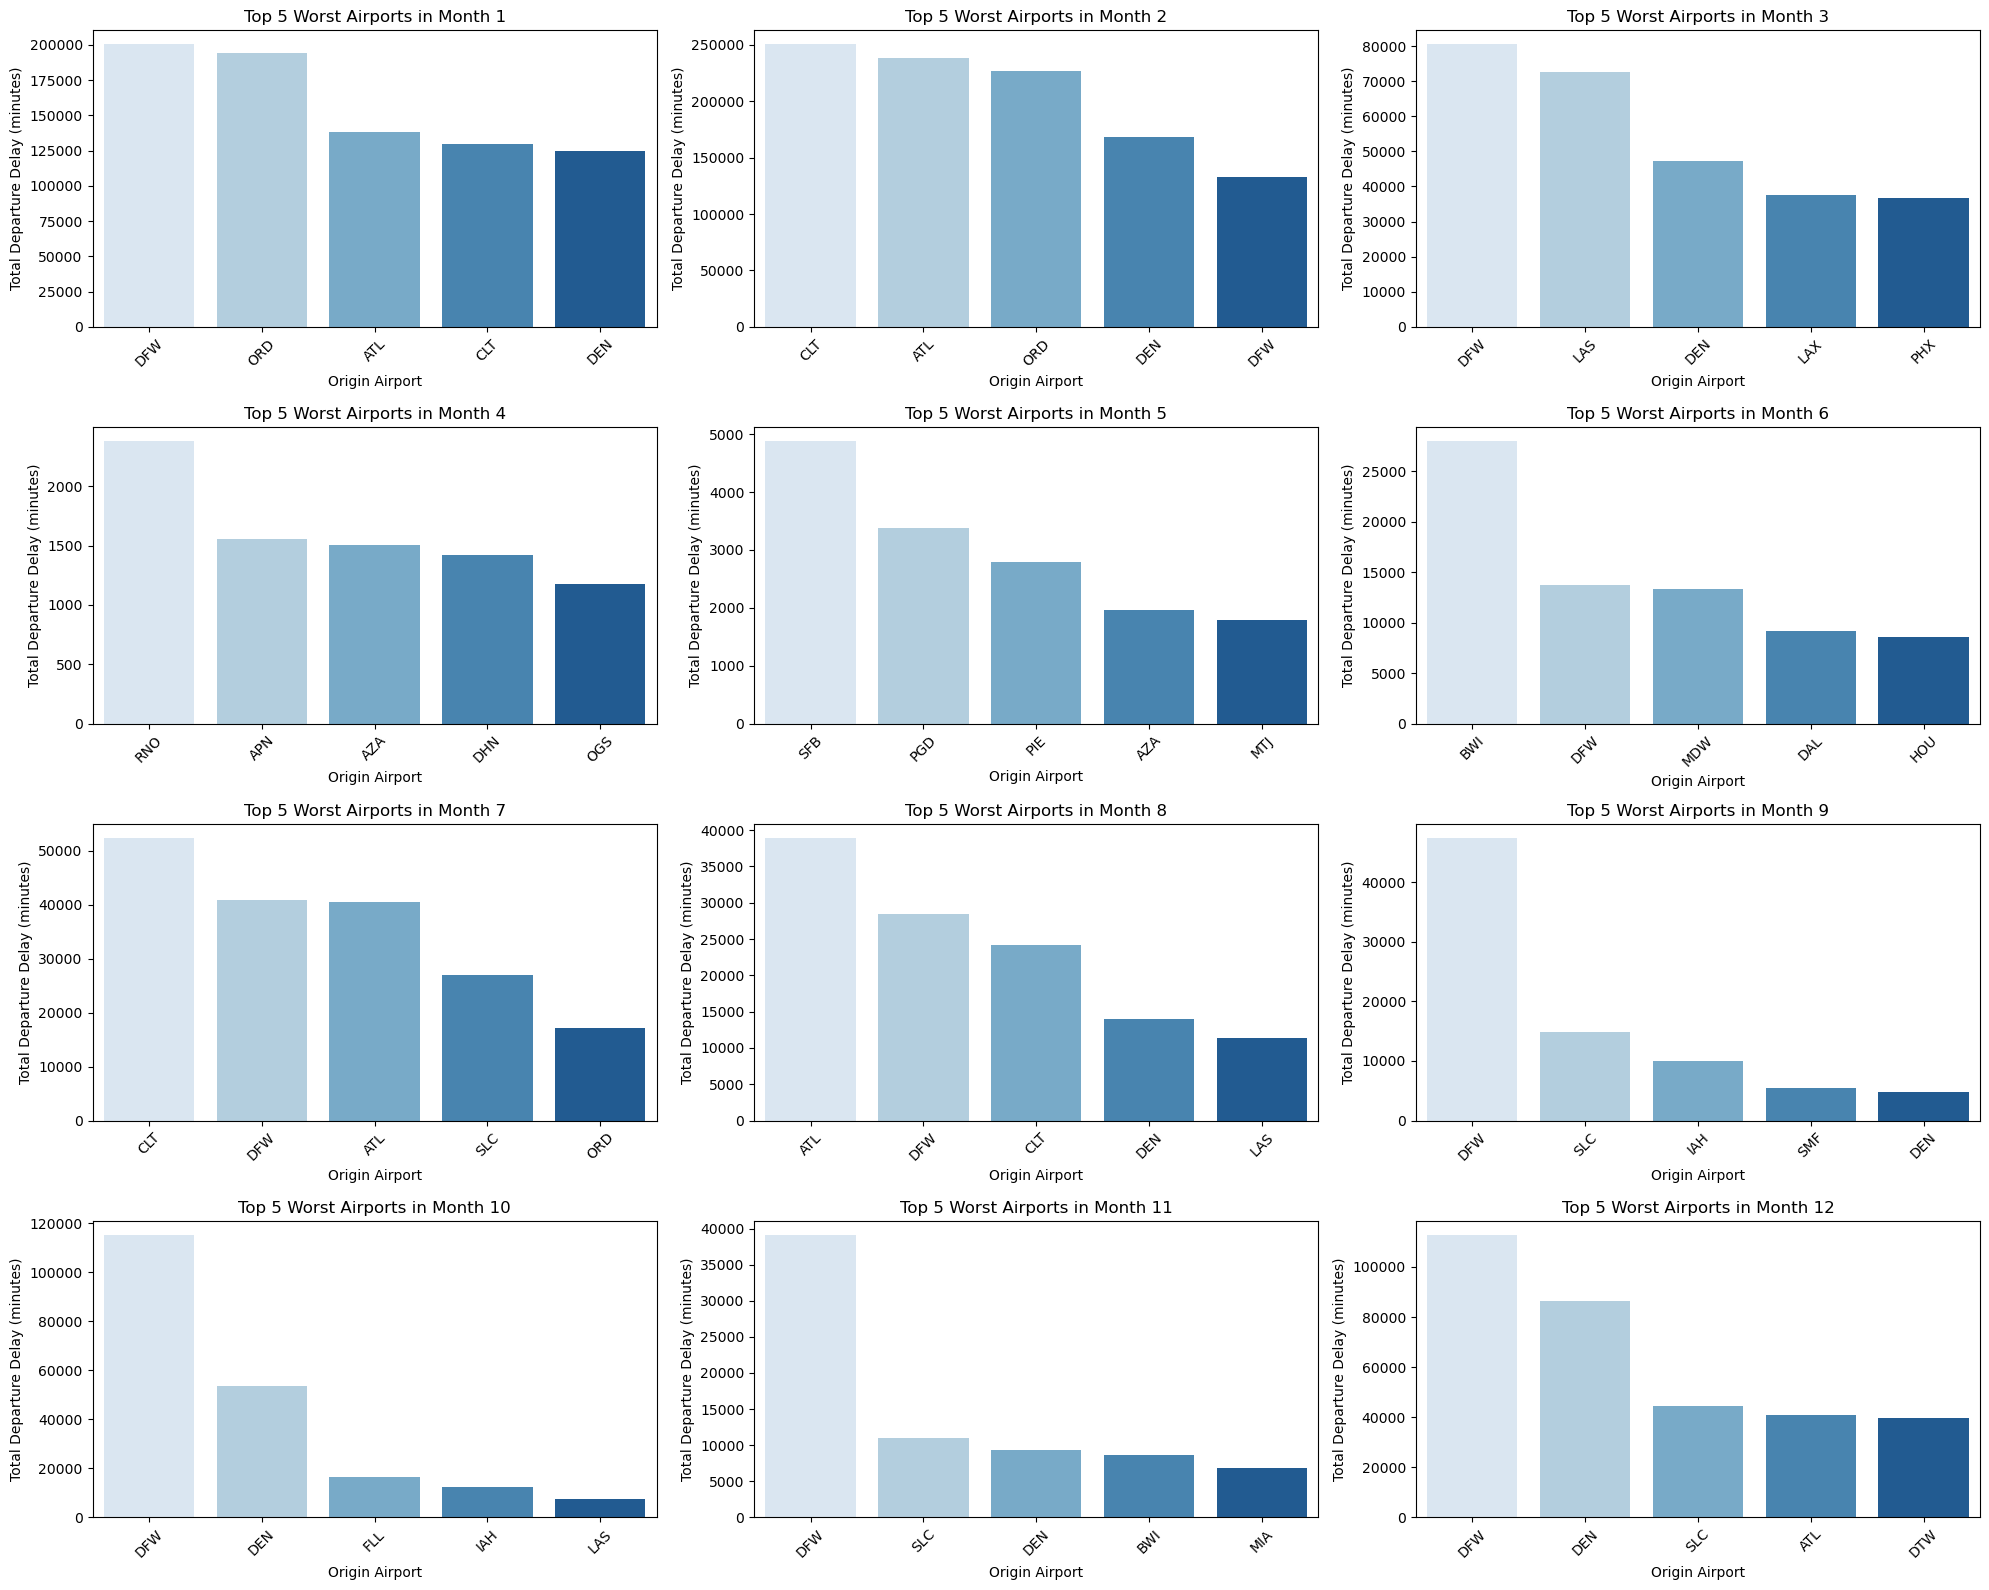

In [25]:
# Reset index to make Month and Origin real columns
plot_mo = worst_dep_mo.reset_index()

months = sorted(plot_mo['Month'].unique())
num_months = len(months)

# Always create a grid of subplots (4 rows x 3 columns for 12 months)
rows = 4
cols = 3
fig, axes = plt.subplots(rows, cols, figsize=(20, 16), squeeze=False)
axes = axes.flatten()

# Plot each month in its own subplot
for i, mo in enumerate(months):
    ax = axes[i]
    data = plot_mo[plot_mo['Month'] == mo]

    sns.barplot(
        data=data,
        x='Origin',
        y='total_dep_delays',
        ax=ax,
        palette='Blues'
    )

    ax.set_title(f"Top 5 Worst Airports in Month {mo}", fontsize=12)
    ax.set_xlabel("Origin Airport")
    ax.set_ylabel("Total Departure Delay (minutes)")
    ax.tick_params(axis='x', rotation=45)

# Turn off unused subplots (e.g., if dataset has fewer than 12 months)
for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


/var/folders/hz/d2mv2jxn6fl85mfk3ln_rxz80000gn/T/ipykernel_5243/993512179.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/hz/d2mv2jxn6fl85mfk3ln_rxz80000gn/T/ipykernel_5243/993512179.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


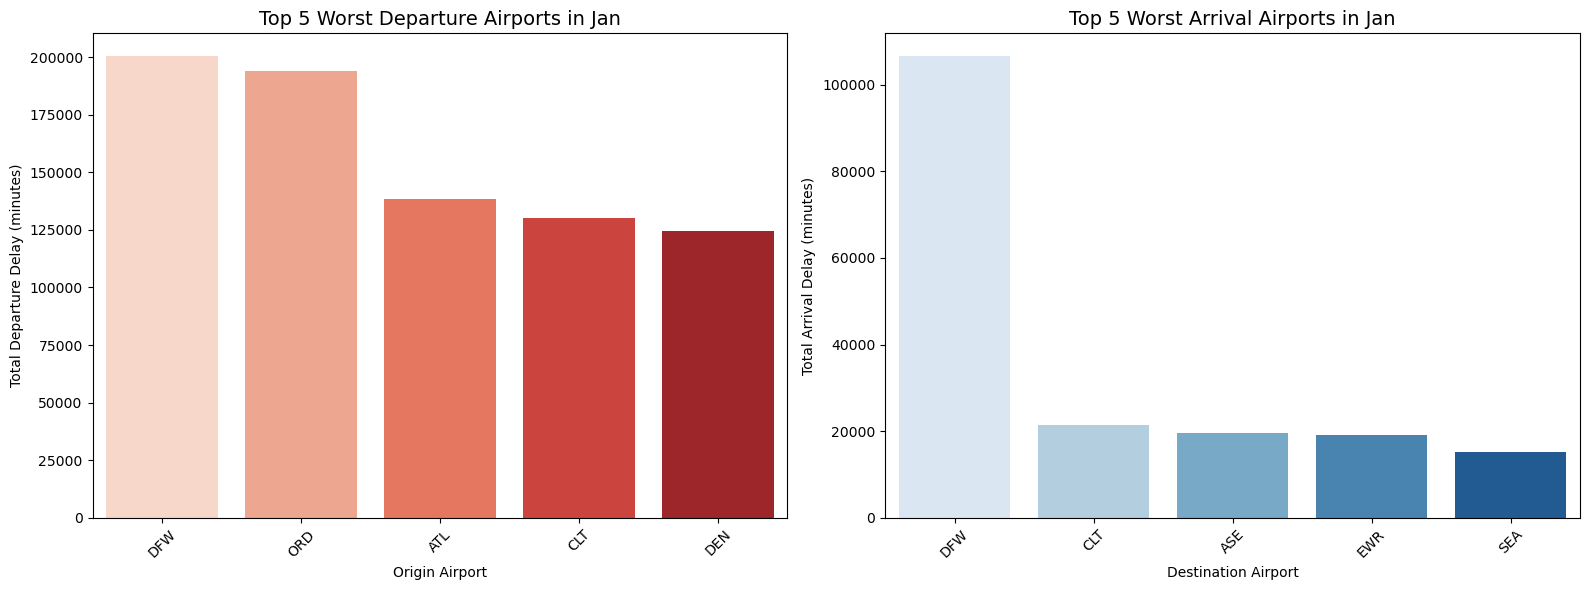

/var/folders/hz/d2mv2jxn6fl85mfk3ln_rxz80000gn/T/ipykernel_5243/993512179.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/hz/d2mv2jxn6fl85mfk3ln_rxz80000gn/T/ipykernel_5243/993512179.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


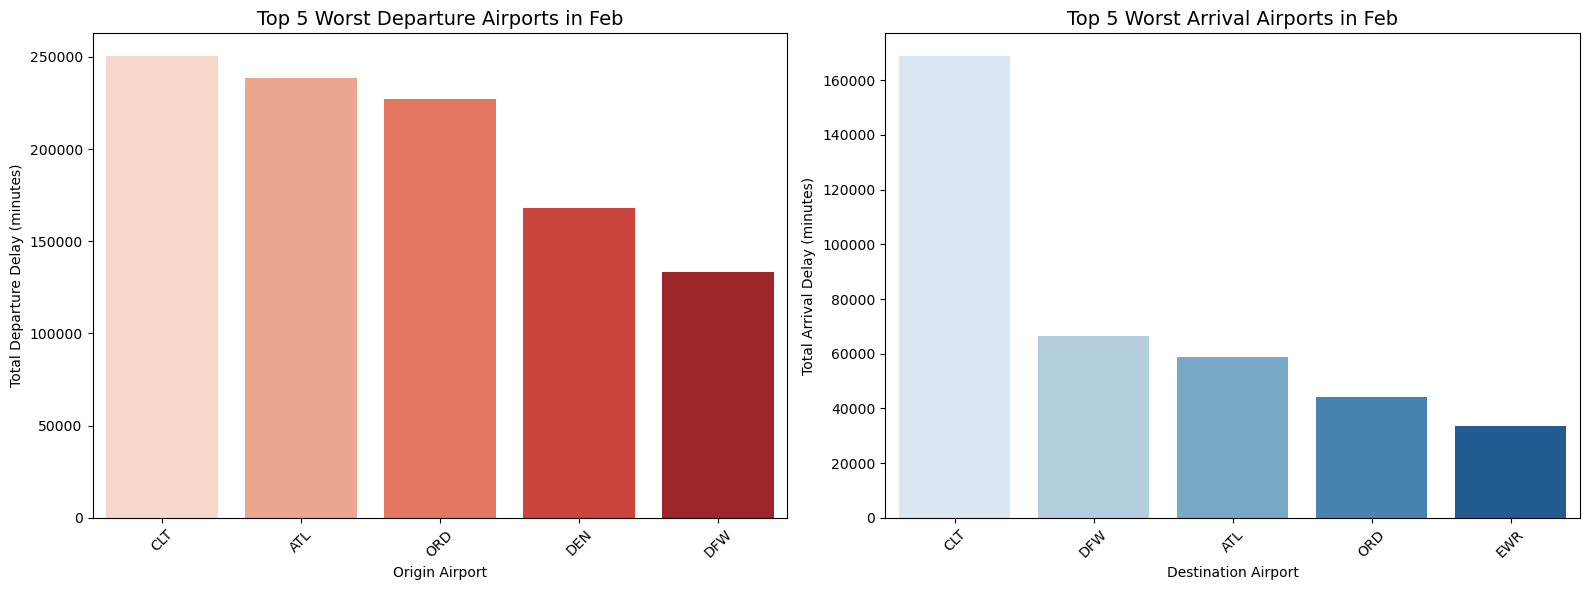

/var/folders/hz/d2mv2jxn6fl85mfk3ln_rxz80000gn/T/ipykernel_5243/993512179.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/hz/d2mv2jxn6fl85mfk3ln_rxz80000gn/T/ipykernel_5243/993512179.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


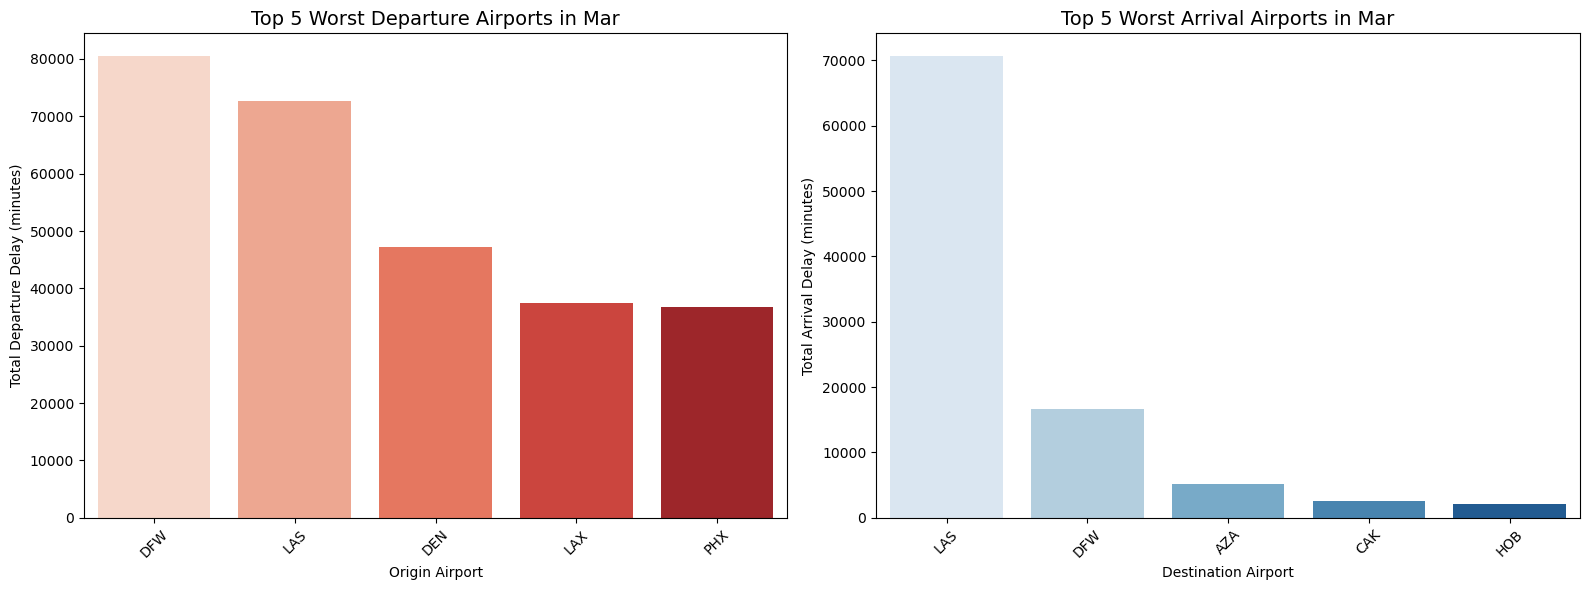

/var/folders/hz/d2mv2jxn6fl85mfk3ln_rxz80000gn/T/ipykernel_5243/993512179.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/hz/d2mv2jxn6fl85mfk3ln_rxz80000gn/T/ipykernel_5243/993512179.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


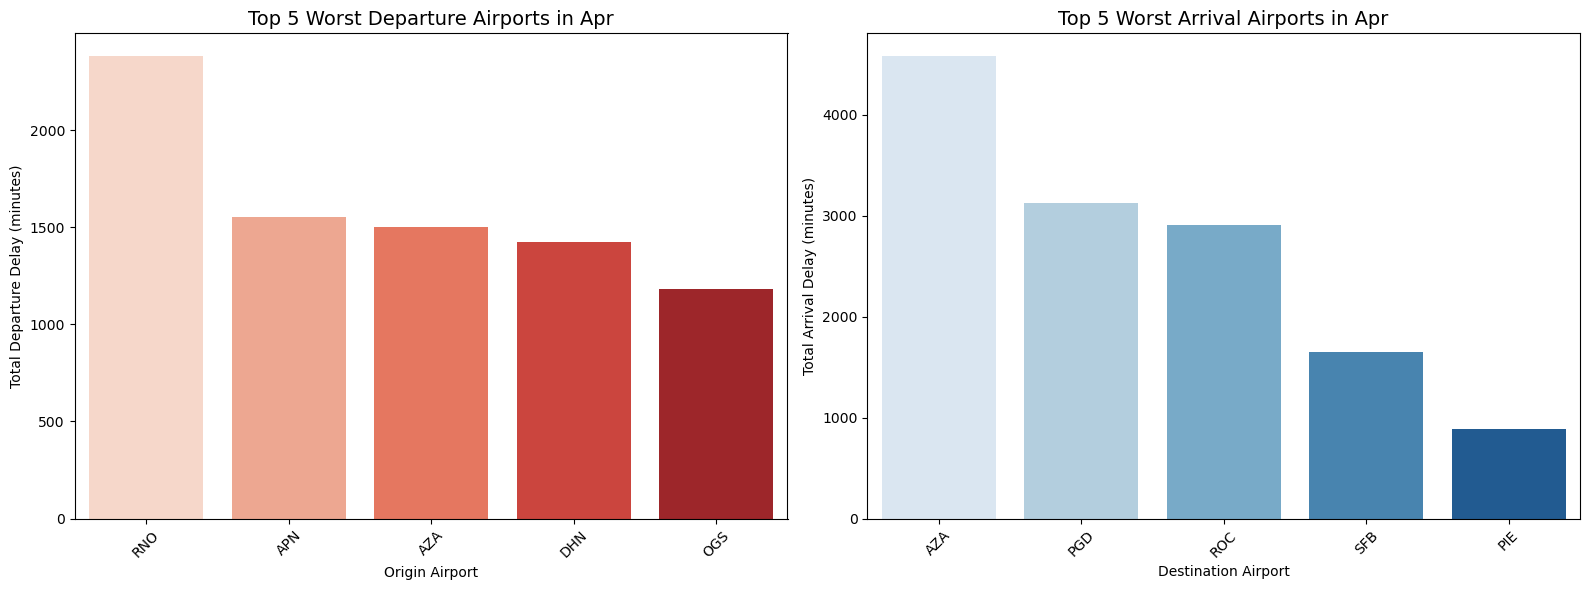

/var/folders/hz/d2mv2jxn6fl85mfk3ln_rxz80000gn/T/ipykernel_5243/993512179.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/hz/d2mv2jxn6fl85mfk3ln_rxz80000gn/T/ipykernel_5243/993512179.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


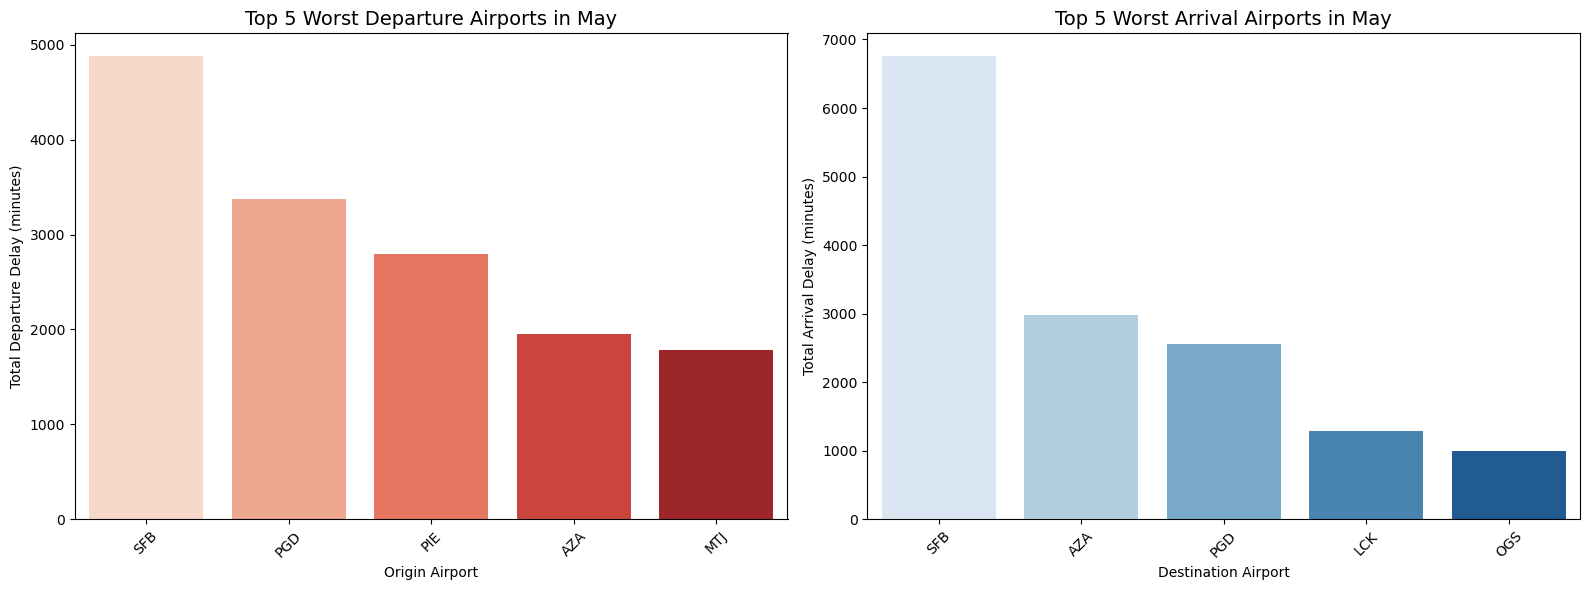

/var/folders/hz/d2mv2jxn6fl85mfk3ln_rxz80000gn/T/ipykernel_5243/993512179.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/hz/d2mv2jxn6fl85mfk3ln_rxz80000gn/T/ipykernel_5243/993512179.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


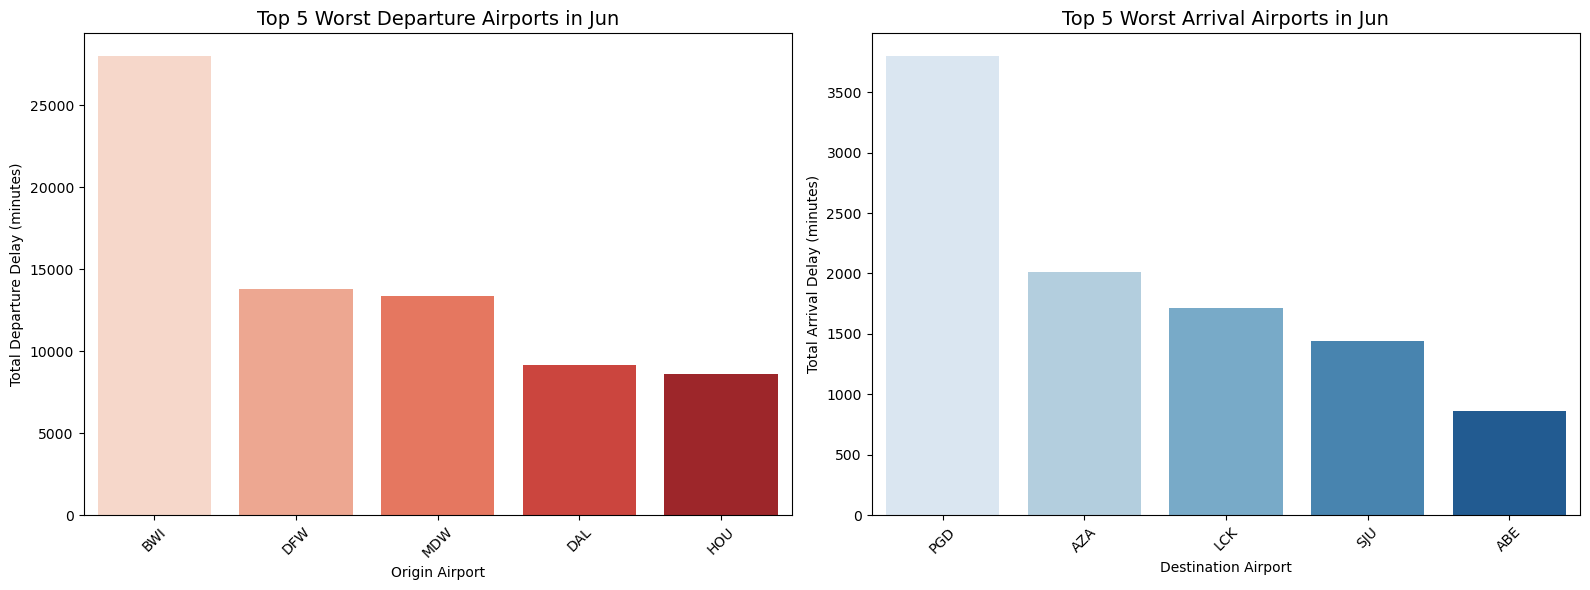

/var/folders/hz/d2mv2jxn6fl85mfk3ln_rxz80000gn/T/ipykernel_5243/993512179.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/hz/d2mv2jxn6fl85mfk3ln_rxz80000gn/T/ipykernel_5243/993512179.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


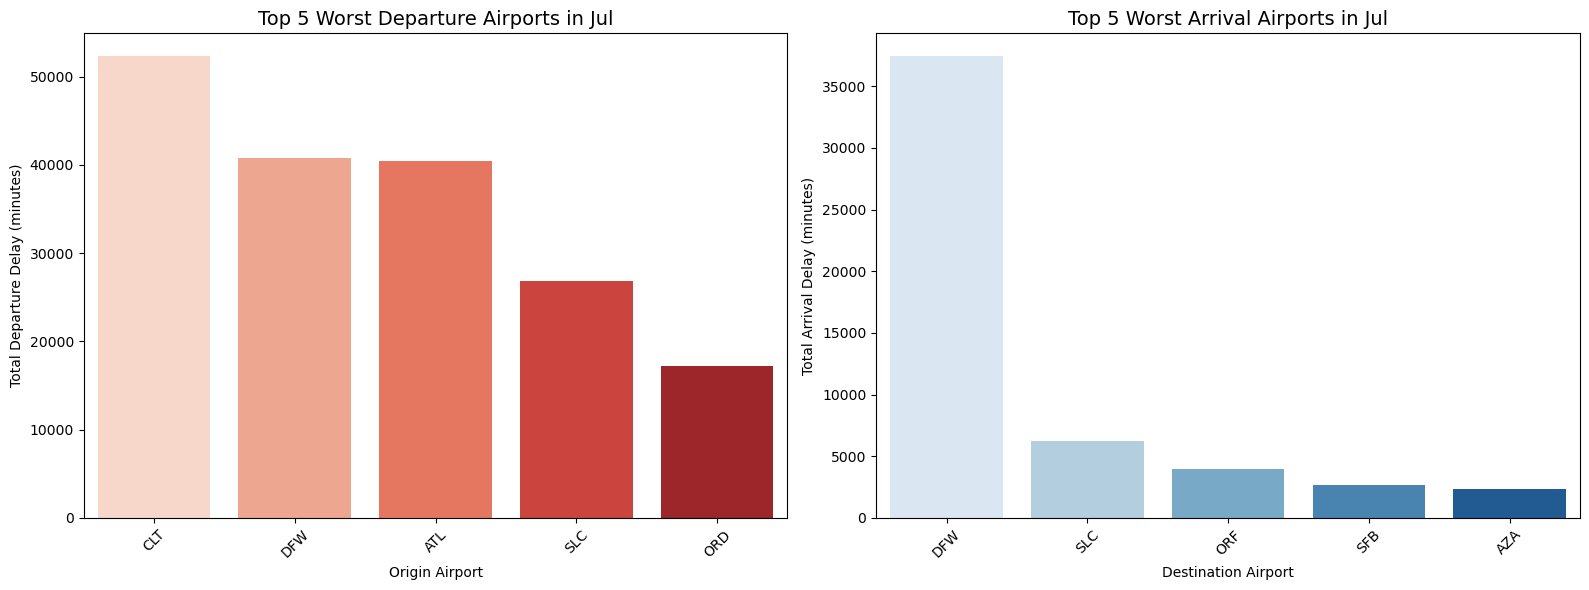

/var/folders/hz/d2mv2jxn6fl85mfk3ln_rxz80000gn/T/ipykernel_5243/993512179.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/hz/d2mv2jxn6fl85mfk3ln_rxz80000gn/T/ipykernel_5243/993512179.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


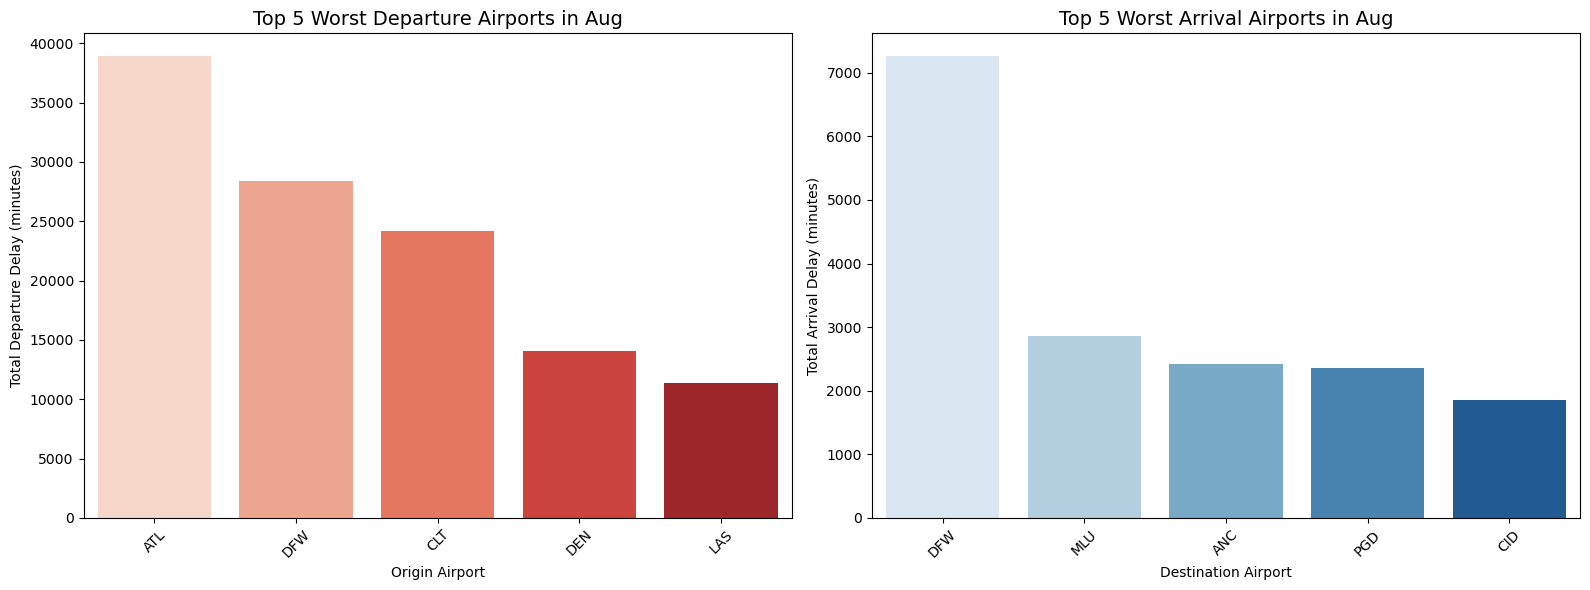

/var/folders/hz/d2mv2jxn6fl85mfk3ln_rxz80000gn/T/ipykernel_5243/993512179.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/hz/d2mv2jxn6fl85mfk3ln_rxz80000gn/T/ipykernel_5243/993512179.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


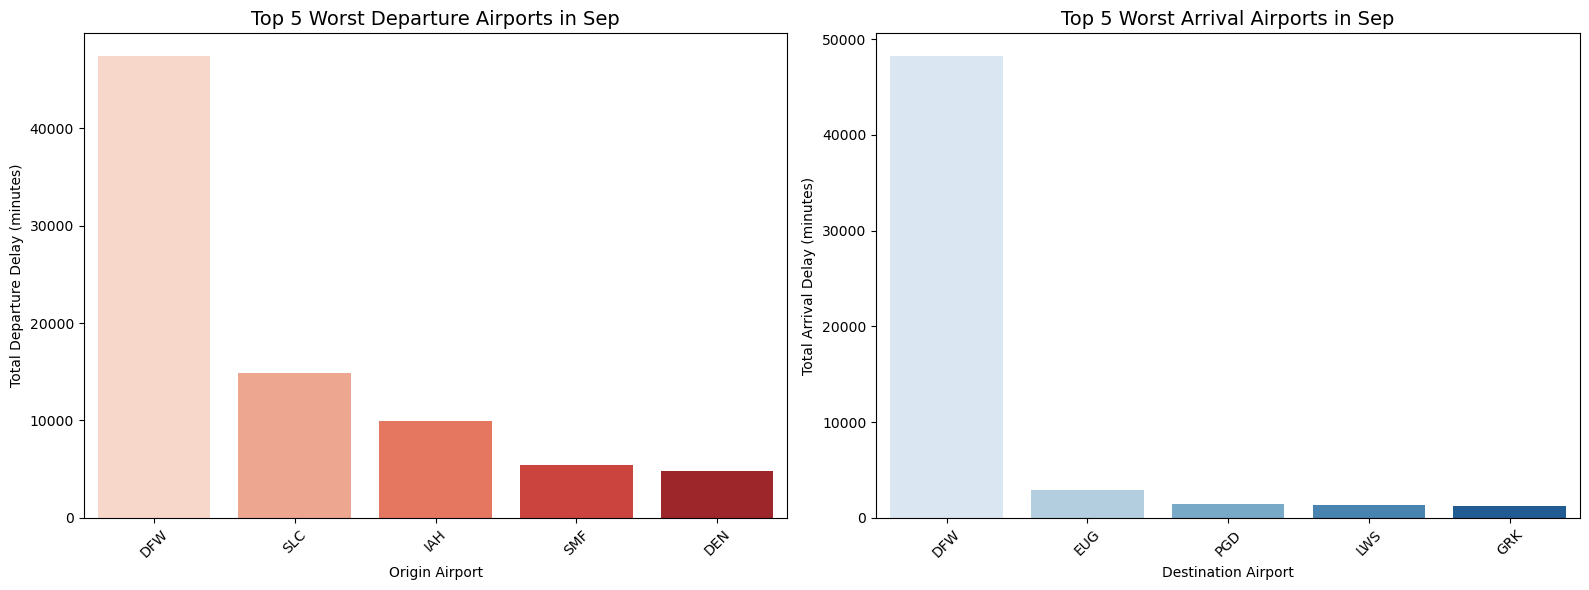

/var/folders/hz/d2mv2jxn6fl85mfk3ln_rxz80000gn/T/ipykernel_5243/993512179.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/hz/d2mv2jxn6fl85mfk3ln_rxz80000gn/T/ipykernel_5243/993512179.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


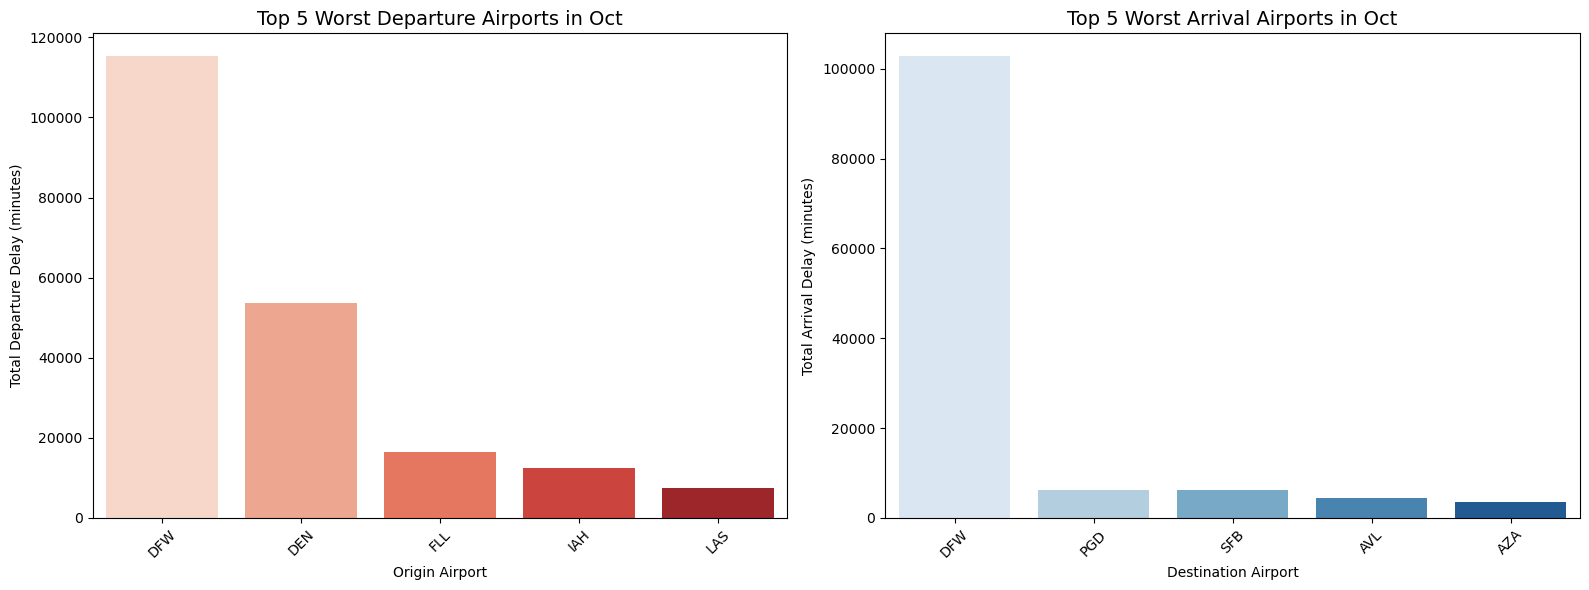

/var/folders/hz/d2mv2jxn6fl85mfk3ln_rxz80000gn/T/ipykernel_5243/993512179.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/hz/d2mv2jxn6fl85mfk3ln_rxz80000gn/T/ipykernel_5243/993512179.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


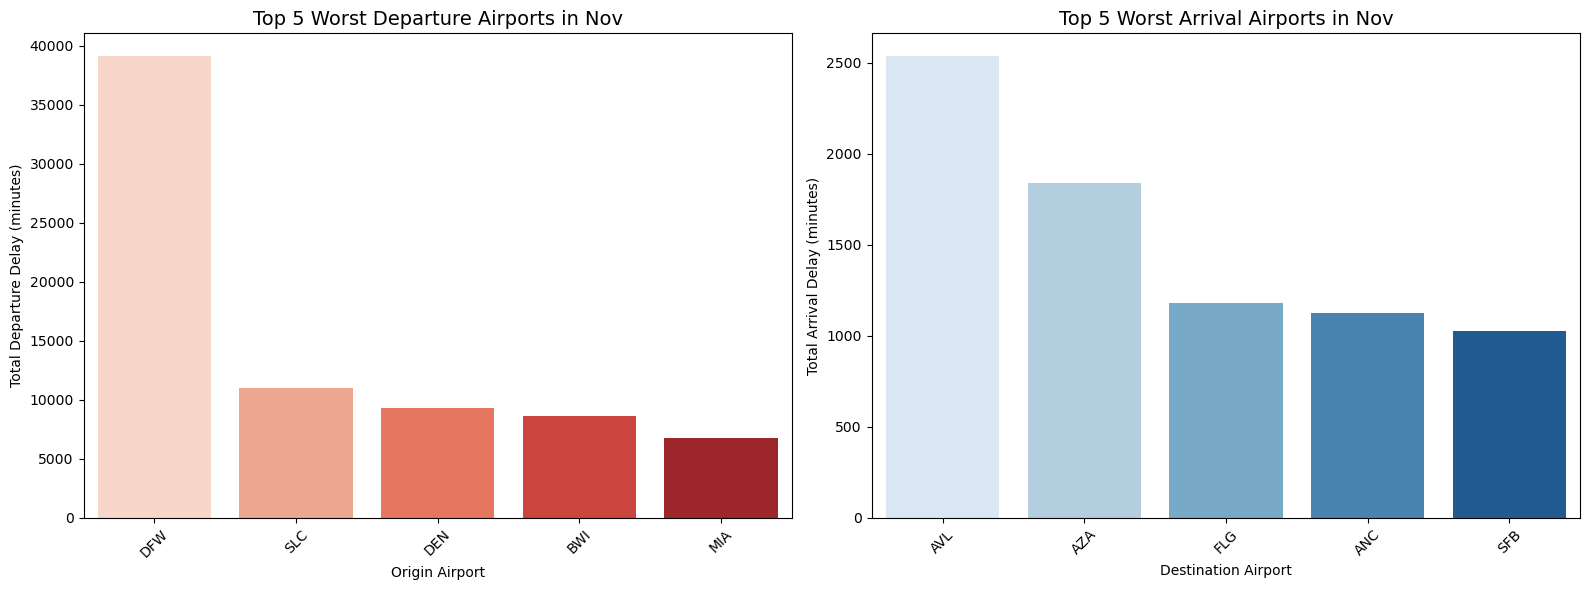

/var/folders/hz/d2mv2jxn6fl85mfk3ln_rxz80000gn/T/ipykernel_5243/993512179.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/hz/d2mv2jxn6fl85mfk3ln_rxz80000gn/T/ipykernel_5243/993512179.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


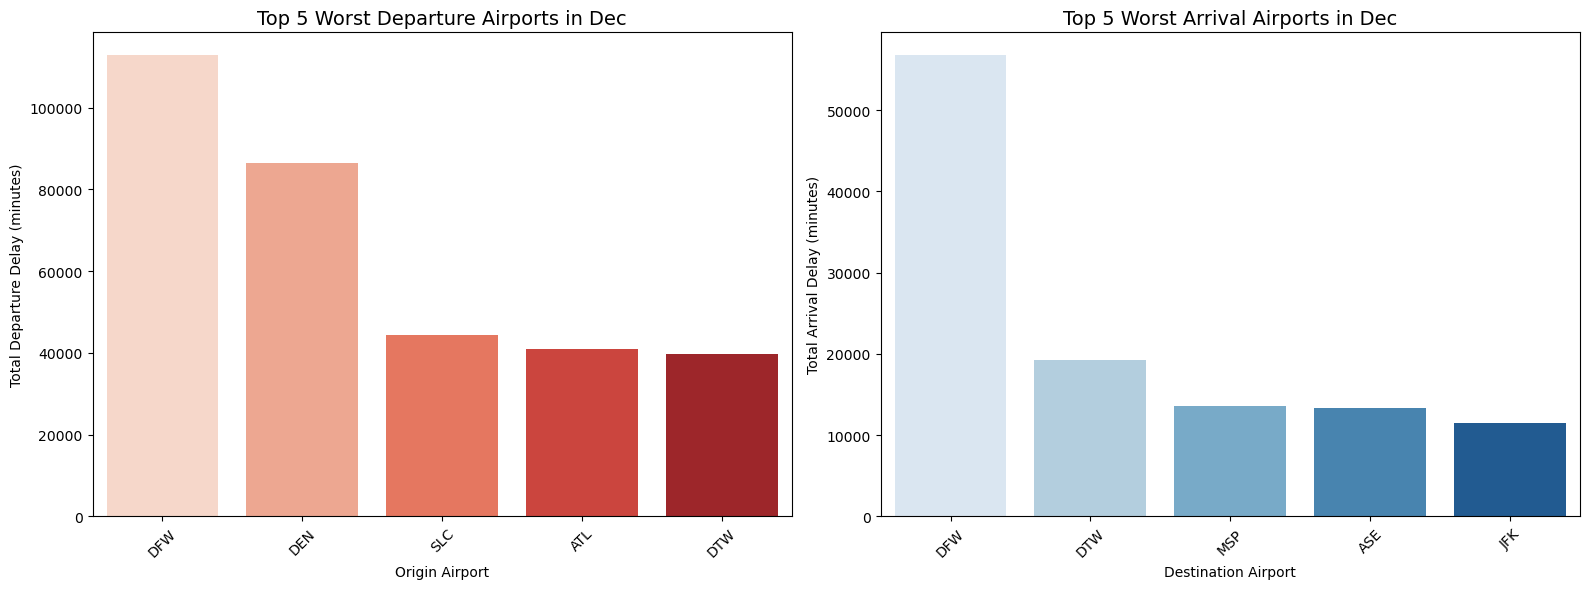

In [39]:
# Reset indices
plot_dep_mo = worst_dep_mo.reset_index()
plot_arr_mo = worst_dest_mo.reset_index()

months = sorted(plot_dep_mo['Month'].unique())

# Optional month name mapping (prettier charts)
month_labels = {
    1:"Jan", 2:"Feb", 3:"Mar", 4:"Apr",
    5:"May", 6:"Jun", 7:"Jul", 8:"Aug",
    9:"Sep", 10:"Oct", 11:"Nov", 12:"Dec"
}

for mo in months:
    dep_data = plot_dep_mo[plot_dep_mo['Month'] == mo]
    arr_data = plot_arr_mo[plot_arr_mo['Month'] == mo]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # ----- LEFT: Departure Delays -----
    sns.barplot(
        data=dep_data,
        x="Origin",
        y="total_dep_delays",
        ax=axes[0],
        palette="Reds"
    )
    axes[0].set_title(f"Top 5 Worst Departure Airports in {month_labels[mo]}", fontsize=14)
    axes[0].set_xlabel("Origin Airport")
    axes[0].set_ylabel("Total Departure Delay (minutes)")
    axes[0].tick_params(axis='x', rotation=45)

    # ----- RIGHT: Arrival Delays -----
    sns.barplot(
        data=arr_data,
        x="Dest",
        y="total_arr_delays",
        ax=axes[1],
        palette="Blues"
    )
    axes[1].set_title(f"Top 5 Worst Arrival Airports in {month_labels[mo]}", fontsize=14)
    axes[1].set_xlabel("Destination Airport")
    axes[1].set_ylabel("Total Arrival Delay (minutes)")
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

We can confirm that consistenly, Dallas Fort-Worth International Airport has the worst departure flight delays of any airport in the U.S.

### Question: What airlines have the best/worst on-time performance?

We will look at this mainly from a departure standpoint 

In [ ]:
df = df.copy()

worst_airline = df.groupby(['Airline']).agg( #groupby year and origin airport to aggegrate sum, mean and median of depdelays per year and sort them in ascending order by total delays
    total_dep_delays=('DepDelay', 'sum'),
    avg_dep_delay=('DepDelay', 'mean'),
    median_dep_delay=('DepDelay', 'median')
).sort_values(['total_dep_delays'], ascending=[False]).groupby('Airline').head(5)
worst_airline


,total_dep_delays,avg_dep_delay,median_dep_delay
Airline,,,
SkyWest Airlines Inc.,2164595.0,3.782472,-4.0
American Airlines,1640347.0,3.062314,-5.0
Southwest Airlines,902684.0,1.021615,-3.0
Delta Airlines,877224.0,1.588046,-4.0
PSA Airlines,864256.0,4.839222,-5.0
United Airlines,560063.0,1.960415,-5.0
Spirit Air Lines,510628.0,3.863564,-3.0
Allegiant Air,497418.0,5.907016,-6.0
Envoy Air,336209.0,1.679634,-5.0


Here we can see that Skywest and American Airline round out the top two worst airlines for departure delays and Alaska and Republic Airlines round out the best for departure delays
Note: A key consideration is that Skywest, PSA, Republic, and Envoy are all subsidiaries of either American, Delta, or United which could add or reduce each airlines performance

# What day of the week has the worst delays?

In [56]:
df = df.copy()
df['day_of_week'] = df['FlightDate'].dt.day_name()
df
day_wk_delay= df.groupby('day_of_week').agg( #groupby month and origin airport to aggegrate sum, mean and median of depdelays per month and sort them in ascending order by total delays
    flights_wk=('FlightDate', 'size'),
    total_day_delays=('DepDelay', 'sum'),
    avg_day_delay=('DepDelay', 'mean'),
    median_day_delay=('DepDelay', 'median')
).sort_values('total_day_delays', ascending=False)
day_wk_delay


,flights_wk,total_day_delays,avg_day_delay,median_day_delay
day_of_week,,,,
Thursday,605771,2002171.0,3.305216,-4.0
Friday,600541,1887512.0,3.143171,-4.0
Sunday,598172,1304289.0,2.180465,-4.0
Saturday,527794,1052622.0,1.994407,-4.0
Monday,602087,986222.0,1.638028,-4.0
Wednesday,560821,641598.0,1.144040,-4.0
Tuesday,532740,440212.0,0.826321,-4.0


<Axes: title={'center': 'Total Departure Delay Minutes by Day of Week'}, xlabel='day_of_week', ylabel='Total Delay (minutes)'>

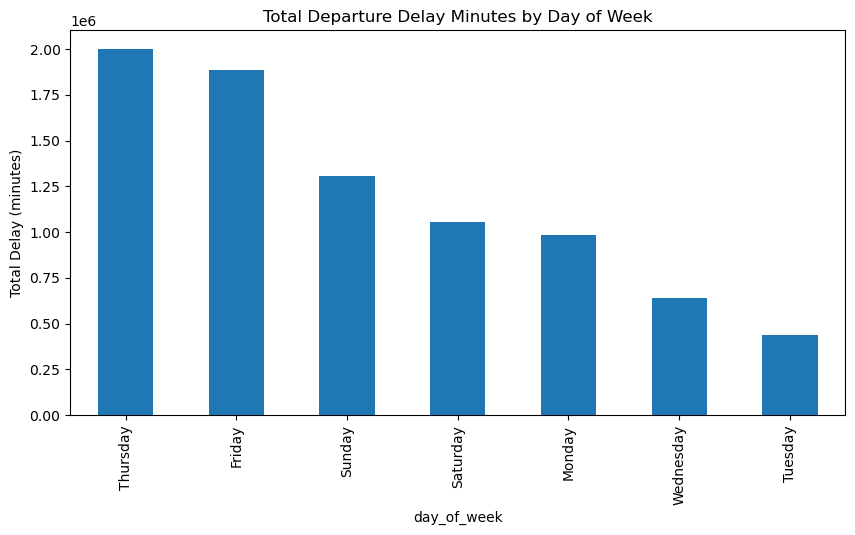

In [57]:
day_wk_delay['total_day_delays'].plot(
    kind='bar',
    figsize=(10,5),
    title='Total Departure Delay Minutes by Day of Week',
    ylabel='Total Delay (minutes)'
)

<Axes: title={'center': 'Average Departure Delay by Day of Week'}, xlabel='day_of_week', ylabel='Average Delay (minutes)'>

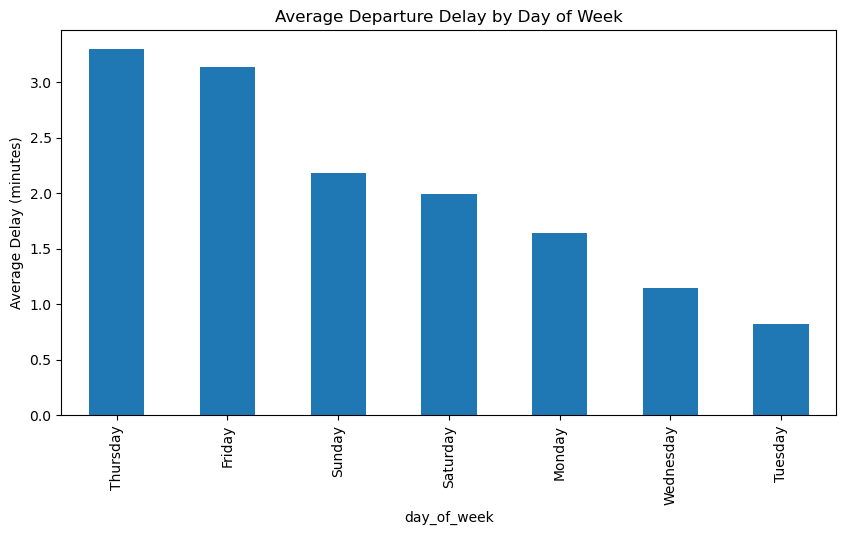

In [58]:
day_wk_delay['avg_day_delay'].plot(
    kind='bar',
    figsize=(10,5),
    title='Average Departure Delay by Day of Week',
    ylabel='Average Delay (minutes)'
)

This would make sense as Thursday and Friday are typically when people will fly out to go on a vacation

<Axes: title={'center': 'Number of Flights by Day of Week'}, xlabel='day_of_week', ylabel='Number of Flights'>

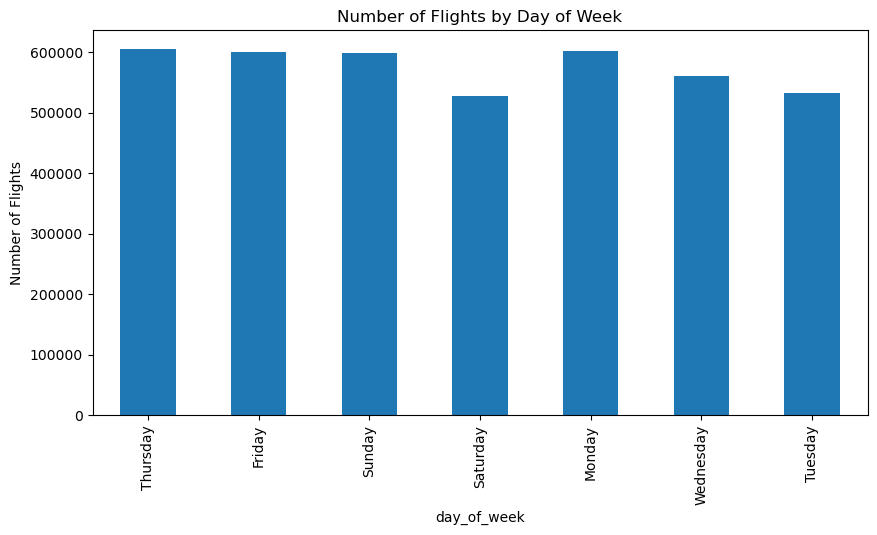

In [59]:
day_wk_delay['flights_wk'].plot(
    kind='bar',
    figsize=(10,5),
    title='Number of Flights by Day of Week',
    ylabel='Number of Flights'
)

### What day of the week has the worst delays across airlines?

In [ ]:
df = df.copy()
df['day_of_week'] = df['FlightDate'].dt.day_name()
air_delay_wk = df.groupby(['Airline', 'day_of_week']).agg(
     flights_wk=('FlightDate', 'size'),
    total_day_delays=('DepDelay', 'sum'),
    avg_day_delay=('DepDelay', 'mean'),
    median_day_delay=('DepDelay', 'median')
).sort_values('Airline', ascending=[False])
air_delay_wk



# worst_dep_mo = df.groupby(['Month', 'Origin']).agg( #groupby month and origin airport to aggegrate sum, mean and median of depdelays per month and sort them in ascending order by total delays
#     total_dep_delays=('DepDelay', 'sum'),
#     avg_dep_delay=('DepDelay', 'mean'),
#     median_dep_delay=('DepDelay', 'median')
# ).sort_values(['Month', 'total_dep_delays'], ascending=[True,False]).groupby('Month').head(5)

flights_wk  total_day_delays  avg_day_delay  \
Airline         day_of_week                                                
United Airlines Wednesday         41192           23393.0       0.567902   
                Tuesday           39798           37908.0       0.952510   
                Thursday          41865          134726.0       3.218106   
                Sunday            41358           87723.0       2.121065   
                Saturday          37839           82123.0       2.170327   
...                                 ...               ...            ...   
Alaska Airlines Sunday            19034          -10551.0      -0.554324   
                Monday            19349          -27278.0      -1.409789   
                Tuesday           18239          -35292.0      -1.934975   
                Wednesday         19383          -41392.0      -2.135480   
                Friday            19431            1133.0       0.058309   

                             median_day_delay  
Airline         day_of_week                    
United Airlines Wednesday                -5.0  
                Tuesday                  -5.0  
                Thursday                 -4.0  
                Sunday                   -4.0  
                Saturday                 -4.0  
...                                       ...  
Alaska Airlines Sunday                   -6.0  
                Monday                   -7.0  
                Tuesday                  -7.0  
                Wednesday                -7.0  
                Friday                   -6.0  

[98 rows x 4 columns]

# What is the likelyhood of a delay based on airline?

In [28]:
#Counting the number of flights for each airline 
df = df.copy()
airline_flights = df.groupby('Airline').size().reset_index(name='number_of_flights').sort_values('number_of_flights', ascending=False) 

#Cleaning DF to only show specified column features as well as only show rows that have departure or arrival delays greater than 0 
df_clean = df[['FlightDate', 'DepDelay', 'ArrDelay', 'Airline']] 
df_delays = df_clean[(df_clean['DepDelay'] > 0) | (df_clean['ArrDelay'] > 0)] 

#Grouping by Airline, showing the number of delays for departure and arrivals respectively 
airline_dep_delay = (df_delays[df_delays['DepDelay']>0].groupby('Airline').size().reset_index(name='Departure_Delays')) 
airline_arr_delay = (df_delays[df_delays['ArrDelay']>0].groupby('Airline').size().reset_index(name='Arrival_Delays')) 
delays = airline_dep_delay.merge(airline_arr_delay, on='Airline', how='outer') 
delays['Total_Delays'] = delays['Departure_Delays'] + delays['Arrival_Delays'] 

#Merging airline_flight DF with delays DF
delays = delays.merge(airline_flights[['Airline', 'number_of_flights']], on='Airline', how='left')

#Percent chance a flight is delayed by airline for either a departure or an arrival 
delays['chance_of_dep_delay'] = ((delays['Departure_Delays'] / airline_flights['number_of_flights'])*100).round(1) 
delays['chance_of_arr_delay'] = ((delays['Arrival_Delays'] / airline_flights['number_of_flights'])*100).round(1)
delays

,Airline,Departure_Delays,Arrival_Delays,Total_Delays,number_of_flights,chance_of_dep_delay,chance_of_arr_delay
0,Alaska Airlines,26660,33720,60380,132466,20.1,25.5
1,Allegiant Air,20438,24949,45387,83694,24.4,29.8
2,American Airlines,115466,130594,246060,534609,21.6,24.4
3,Delta Airlines,97559,128524,226083,551518,17.7,23.3
4,Envoy Air,34573,58580,93153,199712,17.3,29.3
5,Frontier Airlines,16732,19056,35788,86418,19.4,22.1
6,Hawaiian Airlines,7815,9480,17295,38236,20.4,24.8
7,JetBlue Airways,29331,33242,62573,135870,21.6,24.5
8,PSA Airlines,37614,51380,88994,178084,21.1,28.9
9,Republic Airline,25005,38727,63732,208911,12.0,18.5


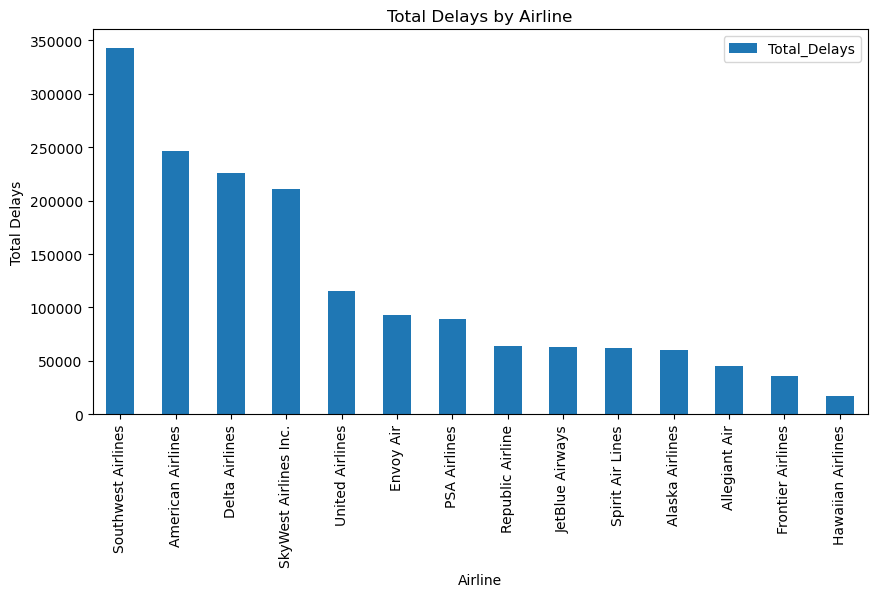

In [29]:
delays.sort_values('Total_Delays', ascending=False).plot(
    x='Airline', y='Total_Delays', kind='bar', figsize=(10,5), title='Total Delays by Airline'
)
plt.ylabel("Total Delays")
plt.show()

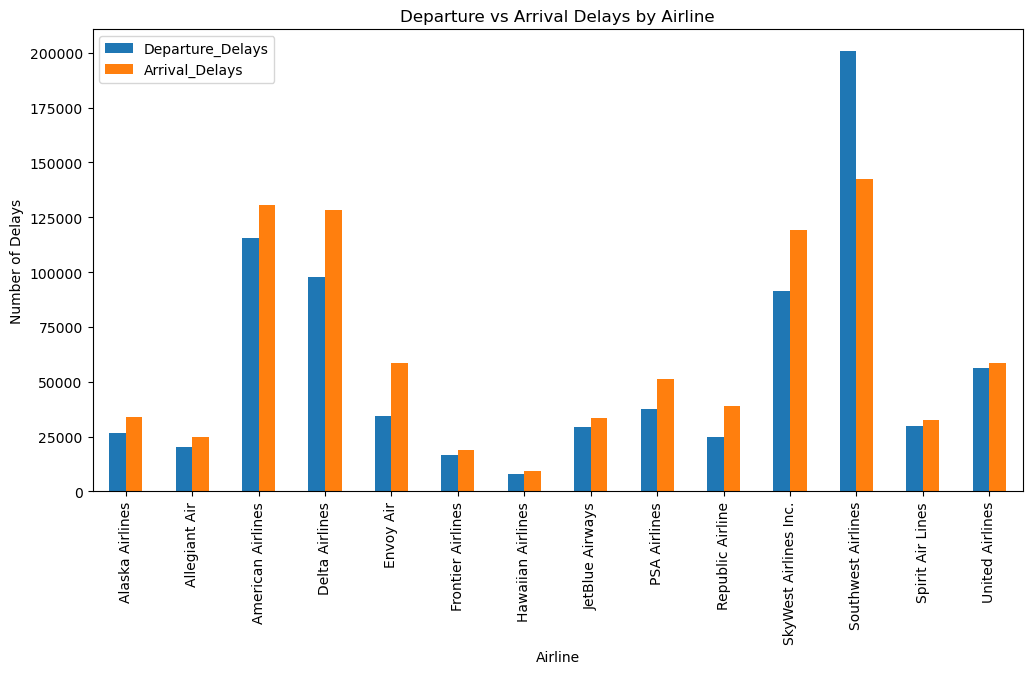

In [30]:
delays.plot(
    x='Airline',
    y=['Departure_Delays', 'Arrival_Delays'],
    kind='bar',
    figsize=(12,6),
    title='Departure vs Arrival Delays by Airline'
)
plt.ylabel("Number of Delays")
plt.show()

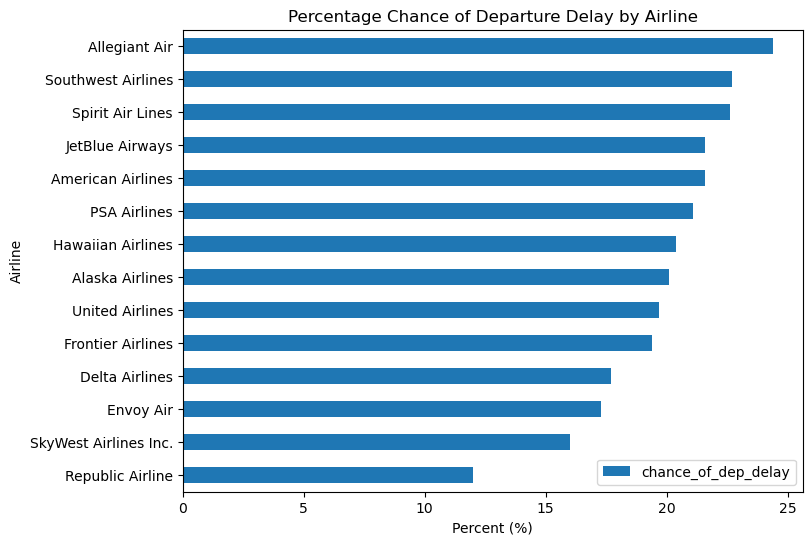

In [31]:
delays.sort_values('chance_of_dep_delay').plot(
    x='Airline',
    y='chance_of_dep_delay',
    kind='barh',
    figsize=(8,6),
    title='Percentage Chance of Departure Delay by Airline'
)
plt.xlabel("Percent (%)")
plt.show()

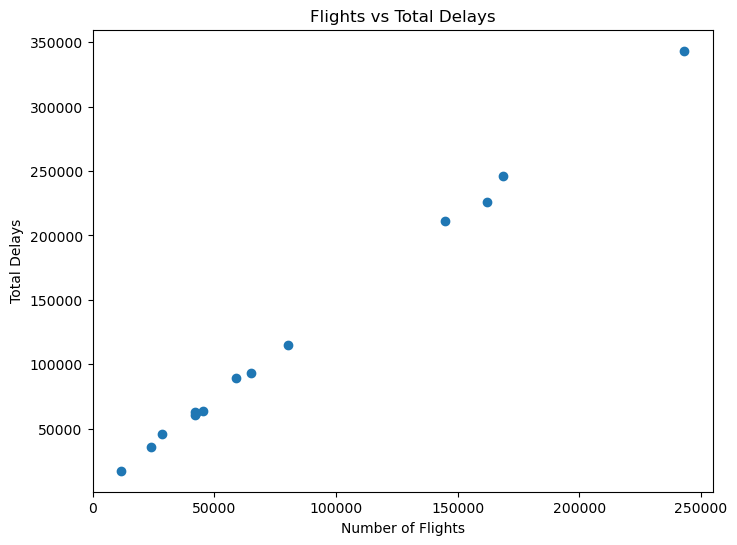

In [52]:
plt.figure(figsize=(8,6))
plt.scatter(delays['number_of_flights'], delays['Total_Delays'])
plt.xlabel("Number of Flights")
plt.ylabel("Total Delays")
plt.title("Flights vs Total Delays")
plt.show()

# Brandon Inputs

In [32]:
df.tail()

,FlightDate,Tail_Number,Origin,OriginCityName,OriginStateName,Dest,DestCityName,DestStateName,CRSDepTime,DepTime,...,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,CRSDepDateTime,Manufacturer,MODEL,Airline,flight_type
4688348,2020-04-01,653RW,CMH,"Columbus, OH",Ohio,IAD,"Washington, DC",Virginia,615,610.0,...,NaN,NaN,NaN,NaN,NaN,2020-04-01 06:15:00,EMBRAER,ERJ 170-100 SE,Republic Airline,Domestic
4688350,2020-04-01,645RW,CLE,"Cleveland, OH",Ohio,EWR,"Newark, NJ",New Jersey,1700,1652.0,...,NaN,NaN,NaN,NaN,NaN,2020-04-01 17:00:00,NaN,NaN,Republic Airline,Domestic
4688351,2020-04-01,725YX,BUF,"Buffalo, NY",New York,EWR,"Newark, NJ",New Jersey,700,933.0,...,132.0,0.0,0.0,0.0,0.0,2020-04-01 07:00:00,EMBRAER S A,ERJ 170-200 LR,Republic Airline,Domestic
4688352,2020-04-01,730YX,HRL,"Harlingen/San Benito, TX",Texas,IAH,"Houston, TX",Texas,730,720.0,...,NaN,NaN,NaN,NaN,NaN,2020-04-01 07:30:00,EMBRAER S A,ERJ 170-200 LR,Republic Airline,Domestic
4688353,2020-04-01,861RW,DCA,"Washington, DC",Virginia,ORD,"Chicago, IL",Illinois,845,837.0,...,NaN,NaN,NaN,NaN,NaN,2020-04-01 08:45:00,EMBRAER,ERJ 170-100 SE,Republic Airline,Domestic


In [ ]:
# I DONT THINK WE NEED THIS ANYMORE

# df_aircraft = pd.read_csv("../data/Raw/Aircraft.csv")
# df_aircraft

In [ ]:
# I DON'T THINK WE NEED THIS ANYMORE


# #Changing feature names for aircraft DF
# mod_aircraft = df_aircraft.rename(columns= {
#     'N-NUMBER': 'Tail_Number',
#     'MFR': 'Manufacturer',
#     'NO-SEATS': 'Number_of_Seats'
# })
# mod_aircraft

# df_merged = df.merge(mod_aircraft, on='Tail_Number', how='left')
# df_merged

## How do routes correlate with delays?
We're looking to assess how delays vary by route. In this context, we'll define a route as a departure/arrival airport pair.  We are interested in identifying the routes with the highest average delay per flight. 

In [79]:
#create a route column from origin and destination columns
df = df.copy()
df["route"] = df["Origin"] + "_" + df["Dest"]

#build a dataframe of flight delay information for each route
route_delay = (
    df.groupby("route")
      .agg(total_arr_delay=("ArrDelay", "sum"),
           n_flights=("ArrDelay", "count"))
      .sort_values("n_flights", ascending=False)
)

In [80]:
route_delay['avg_delay_per_flight'] = route_delay['total_arr_delay'] / route_delay['n_flights']
route_delay.head()

,total_arr_delay,n_flights,avg_delay_per_flight
route,,,
SFO_LAX,-115906.0,8020,-14.452120
LAX_SFO,-94561.0,8007,-11.809791
LAX_LAS,-43031.0,6691,-6.431176
LAS_LAX,-62372.0,6654,-9.373610
PHX_DEN,-35583.0,6068,-5.864041


#### Establish a minimum number of flights
To avoid the results being skewed by routes with very few flights, we'll establish a minimum threshold of number of flights in order for a route to be considered in the analysis. To do this, we'll start with a cutoff that includes 80% of all flights and adjust as necessary.

In [81]:
# Compute the cumulative percentage of total flights as routes are sorted by descending flight count
route_delay["cumulative_share"] = route_delay["n_flights"].cumsum() / route_delay["n_flights"].sum()
route_delay

,total_arr_delay,n_flights,avg_delay_per_flight,cumulative_share
route,,,,
SFO_LAX,-115906.0,8020,-14.452120,0.001995
LAX_SFO,-94561.0,8007,-11.809791,0.003987
LAX_LAS,-43031.0,6691,-6.431176,0.005652
LAS_LAX,-62372.0,6654,-9.373610,0.007307
PHX_DEN,-35583.0,6068,-5.864041,0.008817
...,...,...,...,...
MSY_SJC,-5.0,1,-5.000000,0.999999
CGI_PAH,-17.0,1,-17.000000,0.999999
PNS_MCI,-19.0,1,-19.000000,1.000000


In [82]:
#Establish 80% cutoff mark
cutoff_row = route_delay[route_delay["cumulative_share"] >= 0.80].iloc[0]
cutoff_value = cutoff_row["n_flights"]
cutoff_value


np.float64(613.0)

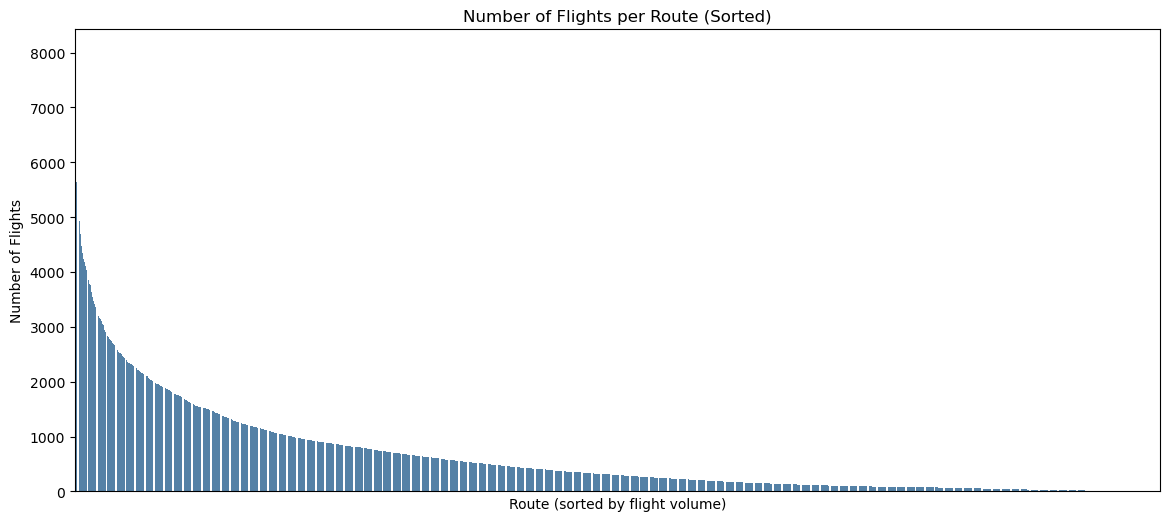

In [83]:
plt.figure(figsize=(14,6))
sns.barplot(
    data=route_delay.sort_values("n_flights", ascending=False),
    x=route_delay.sort_values("n_flights", ascending=False).index,
    y="n_flights",
    color="steelblue"
)
plt.title("Number of Flights per Route (Sorted)")
plt.xlabel("Route (sorted by flight volume)")
plt.ylabel("Number of Flights")
plt.xticks([], [])   #hide x-axis labels
plt.show()

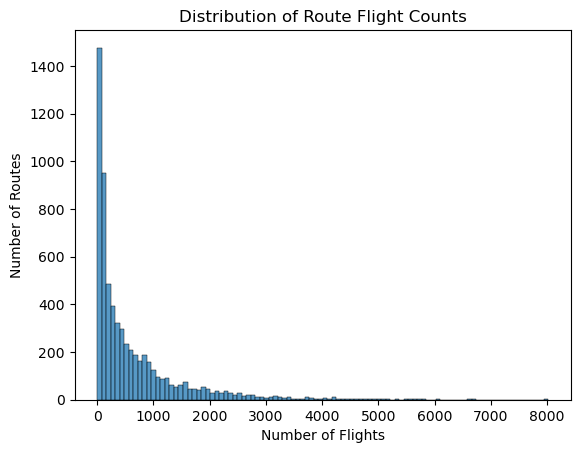

In [84]:
sns.histplot(route_delay["n_flights"], bins=100)
plt.title("Distribution of Route Flight Counts")
plt.xlabel("Number of Flights")
plt.ylabel("Number of Routes")
plt.show()


Given the above histogram and bar char, there is a long tail of lower-volume routes that might be of interest. Let's up the threshold to 95% of flights.

In [85]:
#Establish 95% cutoff mark
cutoff_row = route_delay[route_delay["cumulative_share"] >= 0.95].iloc[0]
cutoff_value = cutoff_row["n_flights"]
cutoff_value

np.float64(197.0)

A minimum threshold of 1623 flights for a route covers 95% of all flights. Now, we'll find the average delay time per flight for all routes with 1623 flights or more.

In [86]:
min_flights = 1623


filtered_routes = route_delay[route_delay["n_flights"] >= min_flights]

# Sort by highest avg delay per flight
filtered_routes = filtered_routes.sort_values(
    "avg_delay_per_flight",
    ascending=False
)
filtered_routes.drop(columns=["cumulative_share"], inplace=True) # cumulative share doesn't make sense in this context



In [87]:
worst_routes = filtered_routes.head()
worst_routes

,total_arr_delay,n_flights,avg_delay_per_flight
route,,,
LIT_DFW,12968.0,1877,6.908897
IAH_DFW,17516.0,2582,6.783888
AUS_DFW,16758.0,2515,6.663221
MEM_DFW,9488.0,1637,5.795968
OKC_DFW,8740.0,1676,5.214797


In [88]:
best_routes = filtered_routes.tail()
best_routes

,total_arr_delay,n_flights,avg_delay_per_flight
route,,,
BOS_SFO,-32361.0,2058,-15.724490
PHL_ORD,-49561.0,3048,-16.260171
LGA_CLT,-42151.0,2577,-16.356616
DCA_ORD,-52775.0,3198,-16.502502
JFK_SFO,-60005.0,3198,-18.763290


### Based on this analysis, there is no standout commonality among the best and worst routes for delays or early arrivals.  Let's explore volume per day at the airports in the top 5 and bottom 5 in the delay data to see if there is a signal there.

In [89]:
top_worst_airports = ["BDL", "SJU", "DCA", "ASE", "DFW", "MDT", "EYW", "PHL"]
top_best_airports  = ["BTM", "SLC", "KOA", "OAK", "RHI", "MSP", "TYS", "DTW", "LIH", "DEN"]

airport_daily_volume = (
    df.melt(
        id_vars=["FlightDate"],
        value_vars=["Origin", "Dest"],
        var_name="type",
        value_name="airport"
    )
    .groupby(["airport", "FlightDate"])
    .size()
    .reset_index(name="flights_per_day")
)


In [90]:
# Average volume / day at the airports in the worst routes
worst_filtered = (
    airport_daily_volume[airport_daily_volume["airport"].isin(top_worst_airports)]
)
worst_filtered_avg = worst_filtered.groupby("airport")["flights_per_day"].mean()

In [91]:
# Average volume / day at the airports in the best routes
best_filtered = (
    airport_daily_volume[airport_daily_volume["airport"].isin(top_best_airports)]
)
best_filtered_avg = best_filtered.groupby("airport")["flights_per_day"].mean()

In [92]:
def create_route_volume_df(route_df,filtered_avg):
    """
    Given a dataframe of routes and a series of averages,
    create a dataframe of routes with volume totals and differences
    """
    rows = []
    for route in route_df.index:
        origin,dest = route.split("_")
        volume_diff = filtered_avg[origin] - filtered_avg[dest]
        total_volume = filtered_avg[origin] + filtered_avg[dest]
        rows.append({
            "route": route,
            "origin": origin,
            "dest": dest,
            "volume_diff": volume_diff,
            "total_volume": total_volume
        })
    
    return pd.DataFrame(rows).set_index("route")


    
    

In [93]:
best_route_volumes_df = create_route_volume_df(best_routes,best_filtered_avg)
best_route_volumes_df

KeyError: 'BOS'

In [53]:
worst_route_volumes_df = create_route_volume_df(worst_routes,worst_filtered_avg)
worst_route_volumes_df

KeyError: 'LIT'

In [ ]:
#Best vs Worst Average Total Volumes
print("Best Route Total Volume:",best_route_volumes_df['total_volume'].mean())
print("Worst Route Total Volume:",worst_route_volumes_df['total_volume'].mean())

In [ ]:
#Best vs Worst Average Volume Difference
print("Best Route Volume Diff:",best_route_volumes_df['volume_diff'].mean())
print("Worst Route Volume Diff:",worst_route_volumes_df['volume_diff'].mean())

There is signal in both the difference and totals in volumes between an origin and destination worth more exploration. Next, we'll do a regression of these two variables on the entire set.

In [ ]:
avg_daily_volume = airport_daily_volume.groupby("airport")["flights_per_day"].mean()
route_volume_df = create_route_volume_df(route_delay,avg_daily_volume)

In [ ]:
merged_route_volumes = route_volume_df.merge(route_delay,on="route")

In [ ]:
merged_route_volumes = merged_route_volumes[merged_route_volumes["n_flights"] >= min_flights]
merged_route_volumes.head()

In [ ]:
#Single Variate Regression for volume difference
X = merged_route_volumes[["volume_diff"]] #predictor
y = merged_route_volumes["avg_delay_per_flight"] #predictand

X = sm.add_constant(X) #Intercept

# Fit model
model = sm.OLS(y, X).fit()

print(model.summary())


In [ ]:
#Plot Avg Delay per FLight vs Volume Difference

x = merged_route_volumes["volume_diff"]
y = merged_route_volumes["avg_delay_per_flight"]

# Fit linear trend
m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(8,5))
plt.scatter(x, y, alpha=0.4, label="Data")
plt.plot(x, m*x + b, color="red", label="Trend Line")

plt.xlabel("Volume Difference (Origin - Destination)")
plt.ylabel("Average Delay per Flight (min)")
plt.title("Avg Delay per Flight vs Volume Difference")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
#Single Variate Regression for total volume
X = merged_route_volumes[["total_volume"]] #predictor
y = merged_route_volumes["avg_delay_per_flight"] #predictand

X = sm.add_constant(X) #Intercept

# Fit model
model = sm.OLS(y, X).fit()

print(model.summary())

In [ ]:
#Plot Avg Delay per FLight vs Total Volume

x = merged_route_volumes["total_volume"]
y = merged_route_volumes["avg_delay_per_flight"]

# Fit linear trend
m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(8,5))
plt.scatter(x, y, alpha=0.4, label="Data")
plt.plot(x, m*x + b, color="red", label="Trend Line")

plt.xlabel("Total Volume (Origin + Destination)")
plt.ylabel("Average Delay per Flight (min)")
plt.title("Avg Delay per Flight vs Total Volume")
plt.legend()
plt.grid(True)
plt.show()


The total volume of both origin and destination is slightly better predictor of average delay (1.8% contribution to variance based on R-squared) than the volume difference (~0.3% contribution) but both are tiny.  Next, we'll explore the relationship between flight distance and average delay.

In [ ]:
# Initial Histogram of distances
plt.figure(figsize=(10,4))
sns.histplot(df["Distance"], bins=50)
plt.title("Distribution of Flight Distance")
plt.xlabel("Distance (miles)")
plt.show()

In [ ]:
#Random sampling of flight distances vs delays
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df.sample(50000, random_state=42),  
    x="Distance",
    y="ArrDelay",
    alpha=0.25
)
plt.title("Flight Distance vs Arrival Delay")
plt.xlabel("Distance (miles)")
plt.ylabel("Arrival Delay (min)")
plt.grid(True)
plt.show()


In [ ]:
corr = df["Distance"].corr(df["ArrDelay"])
corr

**Correlation (R-squared) is near 0.  As expected, there is almost no relationship between flight delay and flight length, at least as a predictor.** 

In [94]:
dep = df.copy()

# Convert the FlightDate columnn to datetime
dep["FlightDate"] = pd.to_datetime(dep["FlightDate"], errors="coerce")
dep

,FlightDate,Tail_Number,Origin,OriginCityName,OriginStateName,Dest,DestCityName,DestStateName,CRSDepTime,DepTime,...,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,CRSDepDateTime,Manufacturer,MODEL,Airline,flight_type,route
0,2020-09-01,506AE,PHL,"Philadelphia, PA",Pennsylvania,DAY,"Dayton, OH",Ohio,1905,1858.0,...,NaN,NaN,NaN,NaN,2020-09-01 19:05:00,BOMBARDIER INC,CL-600-2C10,PSA Airlines,Domestic,PHL_DAY
1,2020-09-02,512AE,PHL,"Philadelphia, PA",Pennsylvania,DAY,"Dayton, OH",Ohio,1905,1858.0,...,NaN,NaN,NaN,NaN,2020-09-02 19:05:00,BOMBARDIER INC,CL-600-2C10,PSA Airlines,Domestic,PHL_DAY
2,2020-09-03,710PS,PHL,"Philadelphia, PA",Pennsylvania,DAY,"Dayton, OH",Ohio,1905,1855.0,...,0.0,26.0,0.0,0.0,2020-09-03 19:05:00,BOMBARDIER INC,CL-600-2C10,PSA Airlines,Domestic,PHL_DAY
3,2020-09-04,712PS,PHL,"Philadelphia, PA",Pennsylvania,DAY,"Dayton, OH",Ohio,1905,1857.0,...,NaN,NaN,NaN,NaN,2020-09-04 19:05:00,BOMBARDIER INC,CL-600-2C10,PSA Airlines,Domestic,PHL_DAY
4,2020-09-05,705PS,PHL,"Philadelphia, PA",Pennsylvania,DAY,"Dayton, OH",Ohio,1905,1856.0,...,NaN,NaN,NaN,NaN,2020-09-05 19:05:00,BOMBARDIER INC,CL-600-2C10,PSA Airlines,Domestic,PHL_DAY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4688348,2020-04-01,653RW,CMH,"Columbus, OH",Ohio,IAD,"Washington, DC",Virginia,615,610.0,...,NaN,NaN,NaN,NaN,2020-04-01 06:15:00,EMBRAER,ERJ 170-100 SE,Republic Airline,Domestic,CMH_IAD
4688350,2020-04-01,645RW,CLE,"Cleveland, OH",Ohio,EWR,"Newark, NJ",New Jersey,1700,1652.0,...,NaN,NaN,NaN,NaN,2020-04-01 17:00:00,NaN,NaN,Republic Airline,Domestic,CLE_EWR
4688351,2020-04-01,725YX,BUF,"Buffalo, NY",New York,EWR,"Newark, NJ",New Jersey,700,933.0,...,0.0,0.0,0.0,0.0,2020-04-01 07:00:00,EMBRAER S A,ERJ 170-200 LR,Republic Airline,Domestic,BUF_EWR
4688352,2020-04-01,730YX,HRL,"Harlingen/San Benito, TX",Texas,IAH,"Houston, TX",Texas,730,720.0,...,NaN,NaN,NaN,NaN,2020-04-01 07:30:00,EMBRAER S A,ERJ 170-200 LR,Republic Airline,Domestic,HRL_IAH


## Delays

In [95]:
# Turn departure time into a datetime object for better analysis
# This require combining the time information with flight date

# Prep a series of strings to comibe with flight dates
crs_str = (
    dep["CRSDepTime"]
    .astype(str)
    .str.zfill(4)     # "0730", "1745"
)

# Combine FL_DATE + hh:mm into a true datetime
dep["CRSDepDateTime"] = pd.to_datetime(
    dep["FlightDate"].dt.strftime("%Y-%m-%d") + " " +
    crs_str.str.slice(0, 2) + ":" + crs_str.str.slice(2, 4),
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)

# Drop any rows where we still failed to build a datetime
dep = dep[dep["CRSDepDateTime"].notna()].copy()

In [96]:
#Check to see how many rows we lost in the operation
rows_lost = len(df.index) - len(dep.index)
rows_lost

0

We'll first examine the hours of day with the highest and lowest average delay to check for a signal worth exploring.

In [97]:
#  Create Hourly Delay Stats

dep["dep_hour"] = dep["CRSDepDateTime"].dt.hour  # 0–23

hourly_dep_delay = (
    dep.groupby("dep_hour")["DepDelay"]
      .agg(
          n_flights="size",
          avg_dep_delay="mean",
          median_dep_delay="median",
          pct_delayed_15=lambda s: (s >= 15).mean(),
          pct_on_time_or_early=lambda s: (s <= 0).mean()
      )
      .reset_index()
      .sort_values("dep_hour")
)

hourly_dep_delay



,dep_hour,n_flights,avg_dep_delay,median_dep_delay,pct_delayed_15,pct_on_time_or_early
0,0,7382,2.045787,-5.0,0.102005,0.778651
1,1,3163,3.956371,-4.0,0.123617,0.754979
2,2,751,3.491345,-5.0,0.165113,0.711052
3,3,677,4.890694,-5.0,0.155096,0.710487
4,4,301,5.980066,-3.0,0.202658,0.624585
5,5,54194,1.042090,-5.0,0.051925,0.879359
6,6,254452,0.149069,-5.0,0.048375,0.882787
7,7,282442,0.047564,-5.0,0.054585,0.874958
8,8,291775,0.145115,-5.0,0.063984,0.856204
9,9,265408,0.719839,-4.0,0.074101,0.827673


In [98]:
# Hours with the lowest average departure delay
least_delay_hours = (
    hourly_dep_delay
    .sort_values("avg_dep_delay")
    .head(5)
)

# Hours with the highest average departure delay
most_delay_hours = (
    hourly_dep_delay
    .sort_values("avg_dep_delay", ascending=False)
    .head(5)
)

print("Departure hours with lowest average delay:")
display(least_delay_hours)

print("Departure hours with highest average delay:")
display(most_delay_hours)


Departure hours with lowest average delay:


,dep_hour,n_flights,avg_dep_delay,median_dep_delay,pct_delayed_15,pct_on_time_or_early
7,7,282442,0.047564,-5.0,0.054585,0.874958
8,8,291775,0.145115,-5.0,0.063984,0.856204
6,6,254452,0.149069,-5.0,0.048375,0.882787
9,9,265408,0.719839,-4.0,0.074101,0.827673
5,5,54194,1.042090,-5.0,0.051925,0.879359


Departure hours with highest average delay:


,dep_hour,n_flights,avg_dep_delay,median_dep_delay,pct_delayed_15,pct_on_time_or_early
4,4,301,5.980066,-3.0,0.202658,0.624585
3,3,677,4.890694,-5.0,0.155096,0.710487
21,21,88158,4.036752,-4.0,0.128304,0.752479
22,22,59583,4.005589,-4.0,0.122820,0.760217
1,1,3163,3.956371,-4.0,0.123617,0.754979


In [99]:
bins = [0, 6, 10, 14, 18, 22, 24]
labels = [
    "Late Night (00–05)",
    "Morning (06–09)",
    "Late Morning (10–13)",
    "Afternoon (14–17)",
    "Evening (18–21)",
    "Late Evening (22–23)",
]

dep["dep_hour"] = dep["CRSDepDateTime"].dt.hour
dep["dep_window"] = pd.cut(dep["dep_hour"], bins=bins, labels=labels, right=False)

window_delay = (
    dep.groupby("dep_window")["DepDelay"]
      .agg(
          n_flights="size",
          avg_dep_delay="mean",
          median_dep_delay="median",
          pct_delayed_15=lambda s: (s >= 15).mean(),
          pct_on_time_or_early=lambda s: (s <= 0).mean()
      )
      .sort_values("avg_dep_delay")
)

window_delay


/var/folders/hz/d2mv2jxn6fl85mfk3ln_rxz80000gn/T/ipykernel_15029/1891299513.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dep.groupby("dep_window")["DepDelay"]


,n_flights,avg_dep_delay,median_dep_delay,pct_delayed_15,pct_on_time_or_early
dep_window,,,,,
Morning (06–09),1094077,0.260271,-5.0,0.060381,0.860307
Late Night (00–05),66468,1.381477,-5.0,0.063910,0.857480
Late Morning (10–13),1050596,1.701856,-4.0,0.088218,0.802293
Afternoon (14–17),1018516,2.971722,-4.0,0.106420,0.775127
Late Evening (22–23),80320,3.560533,-4.0,0.118015,0.763334
Evening (18–21),709734,3.768994,-4.0,0.121002,0.758643


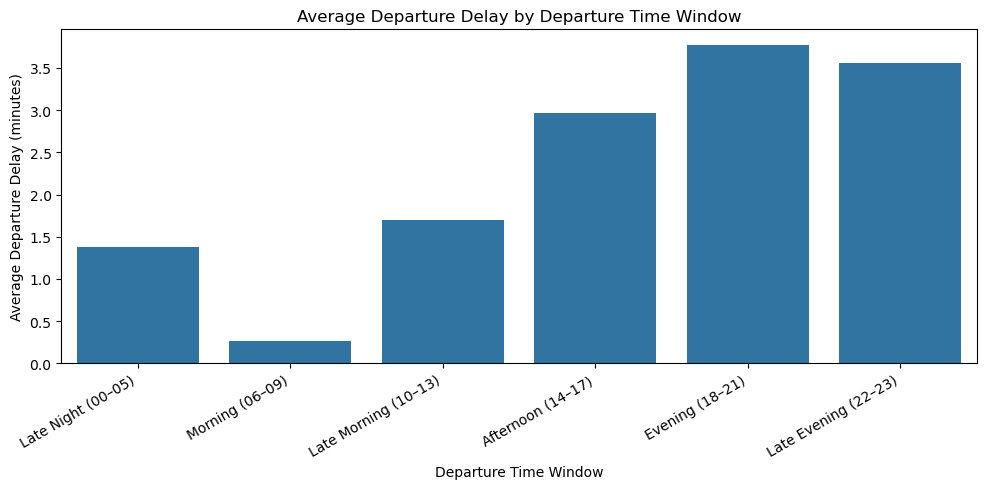

In [116]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=window_delay,
    x="dep_window",
    y="avg_dep_delay"
)
plt.xticks(rotation=30, ha="right")
plt.xlabel("Departure Time Window")
plt.ylabel("Average Departure Delay (minutes)")
plt.title("Average Departure Delay by Departure Time Window")
plt.tight_layout()
plt.show()

#### Conclusion
It's clear that morning flights (6 to 9am) are the best in terms of delays, while afternoon flights are more delay prone.

### Weather Effects on Delays
We'll examine how weather causes delays.  We'll start the exploration with exploring the distribution of delay times throughout the year as well as geographically. 

In [117]:
dep["month"] = dep["FlightDate"].dt.month_name()
dep["month_num"] = dep["FlightDate"].dt.month 

monthly_delay_stats = (
    dep.groupby(["month_num", "month"])["ArrDelay"]
      .agg(
          n_flights="size",
          mean_delay="mean",
          median_delay="median",
          p90_delay=lambda s: s.quantile(0.90),
          total_delay="sum"
      )
      .sort_index()   
)

monthly_delay_stats


,,n_flights,mean_delay,median_delay,p90_delay,total_delay
month_num,month,,,,,
1,January,548464,-1.691478,-10.0,23.0,-927715.0
2,February,518721,-0.305093,-10.0,27.0,-158258.0
3,March,489175,-6.272684,-12.0,15.0,-3068440.0
4,April,169865,-13.724363,-17.0,2.0,-2331289.0
5,May,153074,-11.672302,-14.0,3.0,-1786726.0
6,June,206398,-7.510770,-11.0,8.0,-1550208.0
7,July,321180,-5.360754,-11.0,11.0,-1721767.0
8,August,341518,-6.198657,-11.0,10.0,-2116953.0
9,September,289361,-7.379125,-11.0,7.0,-2135231.0


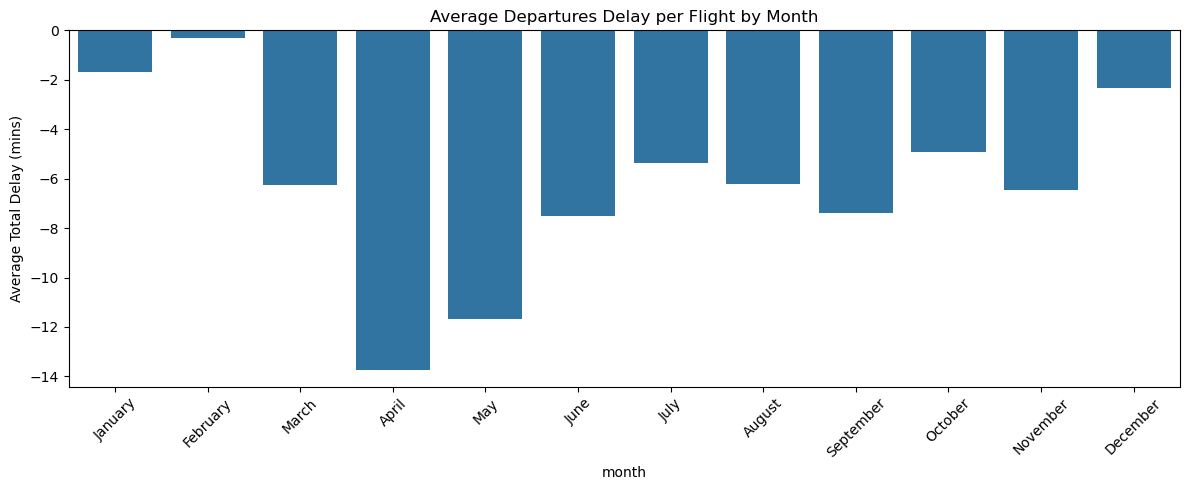

In [118]:
plt.figure(figsize=(12,5))
sns.barplot(
    data=monthly_delay_stats.reset_index(),
    x="month",
    y="mean_delay",
    order=monthly_delay_stats.reset_index()["month"]
)
plt.xticks(rotation=45)
plt.ylabel("Average Total Delay (mins)")
plt.title("Average Departures Delay per Flight by Month")
plt.tight_layout()
plt.show()


In [119]:
#Plotting Flights per month to control for effect of volume on delays
flights_per_month = (
    dep.groupby(["month_num", "month"])
      .size()
      .reset_index(name="n_flights")
      .sort_values("month_num")
)

flights_per_month


,month_num,month,n_flights
0,1,January,548464
1,2,February,518721
2,3,March,489175
3,4,April,169865
4,5,May,153074
5,6,June,206398
6,7,July,321180
7,8,August,341518
8,9,September,289361
9,10,October,318391


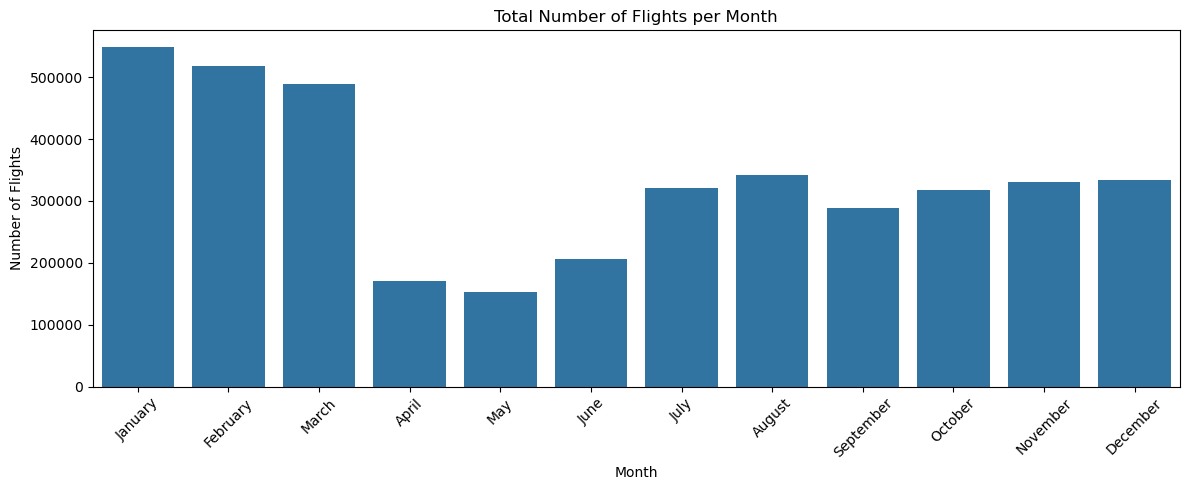

In [120]:
plt.figure(figsize=(12,5))
sns.barplot(
    data=flights_per_month,
    x="month",
    y="n_flights",
    order=flights_per_month["month"]
)

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Number of Flights")
plt.title("Total Number of Flights per Month")
plt.tight_layout()
plt.show()


The relatively uniform distribution of flights tells us we can neglect volume as a factor in monthly delays.  This aligns to our earlier finding that total volume and volume difference contribute very little to delays.

In [121]:
#For averaging purposes, count the number of years each month appears in the record
month_year_count_dict = (
    dep.groupby(dep["FlightDate"].dt.month_name())["FlightDate"]
      .apply(lambda s: s.dt.year.nunique())
      .to_dict()
)
month_year_count_df = (
    pd.DataFrame.from_dict(month_year_count, orient="index", columns=["month_count"])
)
month_year_count_df

NameError: name 'month_year_count' is not defined

In [122]:
wx_delay_totals_by_month = dep.groupby("month")["WeatherDelay"].sum()
monthly_avg_wx_delay = wx_delay_totals_by_month / month_year_count_df["month_count"]
monthly_avg_wx_delay
monthly_avg_wx_delay_df = monthly_avg_wx_delay.reset_index()
monthly_avg_wx_delay_df.columns = ["month", "avg_minutes"]

NameError: name 'month_year_count_df' is not defined

In [83]:
plt.figure(figsize=(12,5))
sns.barplot(
    data=monthly_avg_wx_delay_df,
    x="month",
    y="avg_minutes",
    order=wx_by_month["month"]
)

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Average Weather Delay (minutes)")
plt.title("Average Weather Delay Minutes per Month")
plt.tight_layout()
plt.show()


NameError: name 'monthly_avg_wx_delay_df' is not defined

<Figure size 1200x500 with 0 Axes>

It's apparent the average weather delay per month follows a similar pattern to avereage dealy per flight per month.  Now, we'll examine the percentage of flights with any delay that also had a weather delay on a monthly basis.

In [84]:
#Create a binary column that indicates whether a delay of any type occurred.
#Logic is if either arrival or departure delay is positive, set to 1, otherwise 0
dep["AnyDelay"] = ((dep["DepDelay"] > 0) | (dep["ArrDelay"] > 0)).astype(int)
dep["AnyDelay"]

0          0
1          0
2          1
3          0
4          0
          ..
4688348    0
4688350    0
4688351    1
4688352    0
4688353    0
Name: AnyDelay, Length: 4027926, dtype: int64

In [85]:
monthly_weather_pct = (
    dep.groupby(["month_num", "month"])
      .apply(lambda g: (
          ((g["AnyDelay"] == 1) & (g["WeatherDelay"] > 0)).sum() /
          (g["AnyDelay"] == 1).sum()
      ))
      .reset_index(name="pct_anydelay_with_weather")
      .sort_values("month_num")
)

monthly_weather_pct["pct_anydelay_with_weather"] *= 100
monthly_weather_pct


/var/folders/hz/d2mv2jxn6fl85mfk3ln_rxz80000gn/T/ipykernel_7022/2369183912.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (


,month_num,month,pct_anydelay_with_weather
0,1,January,2.284791
1,2,February,2.562896
2,3,March,1.112199
3,4,April,1.209091
4,5,May,1.724957
5,6,June,2.704989
6,7,July,3.611783
7,8,August,3.557689
8,9,September,2.143040
9,10,October,2.065442


In [ ]:
plt.figure(figsize=(12,5))
sns.barplot(
    data=monthly_weather_pct,
    x="month",
    y="pct_anydelay_with_weather",
    order=monthly_weather_pct["month"]
)

plt.xticks(rotation=45)
plt.ylabel("% of Delayed Flights with Weather Delay")
plt.title("Share of Delayed Flights Attributable to Weather (Monthly)")
plt.tight_layout()
plt.show()


It's clear the weather shares a similar pattern to the overall delays by month, but the low percentages indicate weather isn't generally a major contributor to overall delays. To get a sense of where weather is most likely to be an issue, let's examine the weather delays at the top 100 airports by volume.

In [ ]:
#Create a dataframe of airports with total volume
airport_volume = (
    df.melt(
        id_vars=["FlightDate"],
        value_vars=["Origin", "Dest"],
        var_name="role",
        value_name="airport"
    )
    .groupby("airport")
    .size()
    .reset_index(name="flight_volume")
)
airport_volume

In [ ]:
top100_airports = (
    airport_volume
    .sort_values("flight_volume", ascending=False)
    .head(100)["airport"]
    .tolist()
)


In [ ]:
df["WeatherDelay"] = df["WeatherDelay"].fillna(0)

airport_weather = (
    df.melt(
        id_vars=["WeatherDelay"],
        value_vars=["Origin", "Dest"],
        var_name="role",
        value_name="airport"
    )
    .query("airport in @top100_airports")   # keep only top 100
    .groupby("airport")["WeatherDelay"]
    .sum()
    .reset_index(name="total_weather_delay")
    .sort_values("total_weather_delay", ascending=False)
)

In [ ]:
#Normalize by volume

top100_volume = airport_volume[airport_volume["airport"].isin(top100_airports)]

airport_weather_rate = (
    airport_weather
    .merge(top100_volume, on="airport", how="left")
)

#minnutes per flight
airport_weather_rate["minutes_per_flight"] = (
    airport_weather_rate["total_weather_delay"] /
    airport_weather_rate["flight_volume"]
)

#sort to improve the plot
airport_weather_rate = airport_weather_rate.sort_values(
    "minutes_per_flight",
    ascending=False
)

In [ ]:
plt.figure(figsize=(14,12))

sns.barplot(
    data=airport_weather_rate,
    y="airport",
    x="minutes_per_flight",
    palette="magma"
)

plt.title("Weather Delay Minutes per Flight for Top 100 Airports")
plt.xlabel("Weather Delay Minutes per Flight")
plt.ylabel("Airport")
plt.tight_layout()
plt.show()

In [ ]:
airport_weather_rate.head()

Note the 3 of the top 5 airports for weather delay rate are small regional airports with high volumes.  This indicates that the smaller airports are less equipped to deal with weather impacts and slightly more prone to weather delays. 

#### Weather Delay Conclusions
Based on our analysis, it appears weather delays are overall a minor contributor to the probability of flight delay. There are seasonal variations, but, generally, making flight decisions based on weather factors is not advised, especially if flying through major hubs. 


### Driving questions
    - What percentage of delays are due to security issues?
    - How much time is the average security delay? 


### Phase 1: Load and Initial Reconnaissance

In [ ]:
df.info()

In [ ]:
df.shape

In [ ]:
# Initial Look at security delay
df["SecurityDelay"].describe()


Given the zeroes in the IQR and the very low mean, we can assume security delays are rare.  Given this, we'll focus on non-zero sercurity delays to analyze their characteristics when they do occur. 

In [ ]:
print("Unique origin airports:", df["Origin"].nunique())
print("Unique destination airports:", df["Dest"].nunique())

### Phase 2: Data Quality

In [ ]:
#Ensure security delays are positive values
negative_security = df[df["SecurityDelay"] < 0]
print("Negative SECURITY_DELAY rows:", len(negative_security))

In [ ]:
#Check for NaN
na_counts = df.isna().sum().sort_values(ascending=False)
na_counts

Key columns (FlightDate, Des, Origin,etc.) have no missing values. Missing values are expected in other columns as they are not always reported.

In [ ]:
#Check for outliers, but only evaluate non-zero security delays
sec_pos = df.loc[df["SecurityDelay"] > 0, "SecurityDelay"]

Q1 = sec_pos.quantile(0.25)
Q3 = sec_pos.quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print("IQR:")
print(Q1, Q3, IQR, upper_bound)
outliers = len(df[df["SecurityDelay"] > upper_bound]["SecurityDelay"])
print("Outliers",outliers)
print("Outlier Percent:",outliers/len(sec_pos)*100)


Outlier conlusion:  Only 8% of the sercurity delays are outside the upper bound. Outliers are not a concern for this analysis. 

### Phase 3:  Cleaning Decisions & Implementation

In [ ]:
#Turn flight date into a datetime
df["FlightDate"] = pd.to_datetime(df["FlightDate"], errors="coerce")
df["FlightDate"].head()


### Phase 4:  Statistical EDA

In [ ]:
#Frequency of Sercurity Delays
any_sec_delay = df["SecurityDelay"] > 0

avg_sec_delay_all = df["SecurityDelay"].mean()
avg_sec_delay_pos = df.loc[any_sec_delay, "SecurityDelay"].mean()

print(f"Fraction of flights with any security delay: {sec_delay_rate:.4%}")
print(f"Average security delay given SECURITY_DELAY > 0: {avg_sec_delay_pos:.2f} minutes")


In [ ]:
plt.figure(figsize=(8, 6))
sample = df.loc[any_sec_delay, ["ArrDelay", "SecurityDelay"]].sample(
    min(5000, any_sec_delay.sum()),
    random_state=42
)

sns.scatterplot(data=sample, x="SecurityDelay", y="ArrDelay", alpha=0.3)
plt.title("Arrival Delay vs Security Delay (Sample of Flights with SECURITY_DELAY > 0)")
plt.xlabel("Security Delay (minutes)")
plt.ylabel("Arrival Delay (minutes)")
plt.show()


The above scatter plot reveals an expected pattern:
- No total delays below the security delay time (total delay must be >= any contributor)
- With increasing security delay times, the total delay is more likely to be equal to security delay.

Which airlines have the highest rate of security delay?

In [ ]:
carrier_sec = df.groupby("Reporting_Airline").agg(
    flights=("FlightDate", "count"),
    sec_delay_count=("SecurityDelay", lambda x: (x > 0).sum()),
    avg_sec_delay_positive=("SecurityDelay", lambda x: x[x > 0].mean())
).assign(
    pct_flights_with_sec=lambda x: x["sec_delay_count"] / x["flights"]
).sort_values("pct_flights_with_sec", ascending=False)

carrier_sec.head(10)


In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=carrier_sec.reset_index(),
    x="Reporting_Airline",
    y="pct_flights_with_sec"
)
plt.xticks(rotation=45)
plt.title("Security Delay Frequency by Carrier")
plt.ylabel("Pct Flights with Security Delay")
plt.show()


Spirit Airlines has the highhest delay, but the overall percentage values are very low (<1%).  We can conclude that security delays are not a significant factor in choosing an airline.

However, the average security delay time of 27 minutes begs the question:  Hoe does this length of time compare to other delay types? 

In [ ]:
delay_cols = [
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay"
]

df_delay = df[delay_cols]


In [ ]:
pos_delay_stats = df_delay[df_delay > 0].describe()
pos_delay_stats


Overall, when security delays do happen, they are shorter on average that other delay types, with the exception of NAS delays.

### Phase 5 Feature Engineering

N/A For this question

### Phase 6: Save and Document
Overall, security-related days were a minimal contributor to overall delays.


# Taxi Time

### Phase 1: Load and Initial Reconniassance

In [ ]:
# Load your preprocessed parquet or pickle
df = pd.read_parquet("../data/bts_all.parquet")  # or pd.read_pickle("flights.pkl")

df.head()

In [ ]:
df[["TaxiOut", "DepDelay"]].describe()


### Phase 2: Data Quality Assessment

In [ ]:
taxi_percent_missing = len(df["TaxiOut"]) / df["TaxiOut"].isna().sum()

taxi_percent_missing

Almost half of the te taxi out column is missing.  Is that due airport reporting abilities/  Let's examine the distribution of missing values across airports.

In [ ]:
# Number of missing values per airport
missing_taxis_by_airport = (
    df.groupby("Origin")
      .agg(
          total_flights=("TaxiOut", "size"),
          missing_taxiout=("TaxiOut", lambda x: x.isna().sum())
      )
      .assign(pct_missing=lambda x: x["missing_taxiout"] / x["total_flights"]*100)
      .sort_values("pct_missing", ascending=False)
)

missing_taxis_by_airport


In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=missing_taxis_by_airport,
    x="total_flights",
    y="pct_missing"
)

plt.title("Missing TaxiOut % vs Total Flights by Origin Airport")
plt.show()

Lower volume airports have a slightly higher percentage of missing taxi times, but even the high-volume airports have percentages in 0 to 5% range.  We will just neglect missing values in this analysis.

Now, we'll validate the TaxiOut data using domain logic.

In [ ]:
# Assume Taxi Times less than 0 and greater than 24 hours are erroneous
invalid_taxi = df[(df["TaxiOut"] < 0) | (df["TaxiOut"] > 1440)]


invalid_taxi.shape


In [ ]:
Q1 = df["TaxiOut"].quantile(0.25)
Q3 = df["TaxiOut"].quantile(0.75)
IQR = Q3 - Q1

taxi_outliers = df[(df["TaxiOut"] < Q1 - 1.5*IQR) | (df["TaxiOut"] > Q3 + 1.5*IQR)]
outlier_pct = len(taxi_outliers)/len(df["TaxiOut"])*100
outlier_pct

Only 4% of the taxi times are considered outliers. 

### Phase 4:  Cleaning Decisions
N/A for this dataset

### Phase 5:  Statistical EDA

In [ ]:
#Distribution of TaxiOut and Departure delays
fig, ax = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(df["TaxiOut"], bins=50, ax=ax[0])
ax[0].set_title("Distribution of TaxiOut Times")

sns.histplot(df["DepDelay"], bins=50, ax=ax[1])
ax[1].set_title("Distribution of Departure Delays")

plt.show()


In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="TaxiOut", y="DepDelay", data=df, alpha=0.3)
plt.title("TaxiOut vs. Departure Delay")
plt.show()

In [ ]:
airport_stats = (
    df.groupby("Origin")
        .agg(avg_taxi=("TaxiOut","mean"),
             avg_dep_delay=("DepDelay","mean"),
             flights=("Origin","count"))
        .query("flights > 500")   # avoid small-sample noise
)

airport_stats.head()


In [ ]:
plt.figure(figsize=(10,6))
sns.regplot(data=airport_stats, x="avg_taxi", y="avg_dep_delay")
plt.title("Average Airport Taxi Times and Departure Delays")
plt.show()


We only detect a weak linear relationship between airport average taxi time and average departure delays.

### Phase 5: Transformation


N/A for this question

### Phase 6:  Save and Document

**Conclusion**

Average taxi times are only slightly positively related with average departure delays, indicating taxi times aren't a great contributor to departure delays.  This is probably the result of the fact that departure times already factor taxi times into the predicted departure time. 

# Delay Shocks

### Phase 1: Load and Initial Reconniassance

In [29]:
#Random sample to keep the memory down... temporary measure
df = df.sample(n=100000, random_state=42)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 1370066 to 1844061
Data columns (total 33 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   FlightDate          100000 non-null  object 
 1   Reporting_Airline   100000 non-null  object 
 2   Tail_Number         96759 non-null   object 
 3   Origin              100000 non-null  object 
 4   OriginCityName      100000 non-null  object 
 5   OriginStateName     100000 non-null  object 
 6   Dest                100000 non-null  object 
 7   DestCityName        100000 non-null  object 
 8   DestStateName       100000 non-null  object 
 9   CRSDepTime          100000 non-null  int64  
 10  DepTime             93961 non-null   float64
 11  DepDelay            93959 non-null   float64
 12  TaxiOut             93949 non-null   float64
 13  WheelsOff           93949 non-null   float64
 14  WheelsOn            93911 non-null   float64
 15  TaxiIn              93911 non-nu

In [31]:
df_airline

,OP_UNIQUE_CARRIER,Description
0,AA,American Airlines Inc.
1,AS,Alaska Airlines Inc.
2,B6,JetBlue Airways
3,DL,Delta Air Lines Inc.
4,F9,Frontier Airlines Inc.
5,G4,Allegiant Air
6,HA,Hawaiian Airlines Inc.
7,MQ,Envoy Air
8,NK,Spirit Air Lines
9,OH,PSA Airlines Inc.


In [32]:
# Remove the summary row
df_airline = df_airline[df_airline["OP_UNIQUE_CARRIER"] != "All Rows"]

df = df.merge(
    df_airline[["OP_UNIQUE_CARRIER", "Description"]],
    left_on="Reporting_Airline",
    right_on="OP_UNIQUE_CARRIER",
    how="left"
).rename(columns={"Description": "Airline"})
df

,FlightDate,Reporting_Airline,Tail_Number,Origin,OriginCityName,OriginStateName,Dest,DestCityName,DestStateName,CRSDepTime,...,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,TotalAddGTime,DivAirportLandings,DivReachedDest,OP_UNIQUE_CARRIER,Airline
0,2020-11-04,WN,N8569Z,ATL,"Atlanta, GA",Georgia,FLL,"Fort Lauderdale, FL",Florida,1240,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,WN,Southwest Airlines Co.
1,2020-01-21,WN,N8610A,DEN,"Denver, CO",Colorado,AUS,"Austin, TX",Texas,515,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,WN,Southwest Airlines Co.
2,2020-03-22,AA,N776XF,GRR,"Grand Rapids, MI",Michigan,DFW,"Dallas/Fort Worth, TX",Texas,1534,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,AA,American Airlines Inc.
3,2020-07-08,OH,N613NN,CLT,"Charlotte, NC",North Carolina,SRQ,"Sarasota/Bradenton, FL",Florida,1300,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,OH,PSA Airlines Inc.
4,2020-01-27,WN,N7820L,STL,"St. Louis, MO",Missouri,MKE,"Milwaukee, WI",Wisconsin,910,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,WN,Southwest Airlines Co.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2020-08-28,NK,N932NK,BWI,"Baltimore, MD",Maryland,MCO,"Orlando, FL",Florida,1710,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NK,Spirit Air Lines
99996,2020-10-04,G4,273NV,BLI,"Bellingham, WA",Washington,AZA,"Phoenix, AZ",Arizona,1852,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,G4,Allegiant Air
99997,2020-04-02,AA,N8031M,PSP,"Palm Springs, CA",California,DFW,"Dallas/Fort Worth, TX",Texas,1042,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,AA,American Airlines Inc.
99998,2020-06-10,MQ,N270NN,DFW,"Dallas/Fort Worth, TX",Texas,BOI,"Boise, ID",Idaho,1855,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,MQ,Envoy Air


In [33]:
df["FlightDate"] = pd.to_datetime(df["FlightDate"])


In [34]:

df["CRSDepTime"] = df["CRSDepTime"].astype(str).str.zfill(4)


df["CRSDepDateTime"] = (
    pd.to_datetime(df["FlightDate"])
    + pd.to_timedelta(df["CRSDepTime"].str[:2].astype(int), unit="h")
    + pd.to_timedelta(df["CRSDepTime"].str[2:].astype(int), unit="m")
)

### Phase 2: Data Quality Assessment

In [35]:
# Delay distributions
df[["DepDelay", "ArrDelay"]].describe(percentiles=[0.5, 0.9, 0.95, 0.99])


,DepDelay,ArrDelay
count,93959.000000,93744.000000
mean,2.116859,-4.972606
std,35.684862,37.240002
min,-100.000000,-101.000000
50%,-4.000000,-11.000000
90%,13.000000,14.000000
95%,35.000000,35.000000
99%,131.000000,126.000000
max,1926.000000,1932.000000


In [ ]:
df["Tail_Number"].nunique()


### Phase 3: Cleaning Decisions

### Phase 4: Statistical EDA

In [ ]:
# Overall arrival delay distribution
df["ArrDelay"].hist(bins=100, figsize=(8, 4))
plt.title("Arrival Delay Distribution (Minutes)")
plt.xlabel("Arrival delay (minutes)")
plt.ylabel("Count")
plt.show()


In [ ]:
# Percentage of late arrivals by carrier (using 15-minute threshold)
LATE_THRESHOLD = 15
df["arr_late"] = df["ArrDelay"] > LATE_THRESHOLD

carrier_delay_rates = (
    df.groupby("Airline")["arr_late"]
      .mean()
      .sort_values(ascending=False)
)

carrier_delay_rates.plot.bar(figsize=(10, 4))
plt.title("Percent of Flights Arriving Late (>15 minutes) by Carrier")
plt.ylabel("Late arrival rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

carrier_delay_rates


### Phase 5: Transformation

We are interested in how each carrier resists cascading delays.  We'll need to do some feature transformation to help us with this analysis.

In [ ]:
#Create an hour column
df["DepHour"] = df["CRSDepDateTime"].dt.hour


In [ ]:
avg_delay_by_hour = (
    df.groupby(["Airline", "DepHour"])["DepDelay"]
      .mean()
      .reset_index()
)
avg_delay_by_hour

In [ ]:
plt.figure(figsize=(14, 7))

sns.lineplot(
    data=avg_delay_by_hour,
    x="DepHour",
    y="DepDelay",
    hue="Airline",
    marker="o"
)

plt.title("Average Departure Delay by Hour of Day for Each Airline", fontsize=16)
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Average Departure Delay (minutes)")
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24))

plt.show()


It's clear in the chart above, the delays grow throughout the day for all airlines, but not at the same rate. Dispersion is smallest around 7am and grows to maximum spread at aroun 9pm. To further evaluate, we'll look at the difference in average flight delays between 7am and 9pm for each airline. **NOTE: This is  less noisy with more data**



In [ ]:
subset = avg_delay_by_hour[avg_delay_by_hour["DepHour"].isin([7, 21])]

#Make 7 and 21 hours columns
pivot = subset.pivot(index="Airline", columns="DepHour", values="DepDelay")
pivot = pivot.rename(columns={7: "delay_7", 21: "delay_21"})
pivot["difference_21_minus_7"] = pivot["delay_21"] - pivot["delay_7"]
pivot

In [ ]:
delay_diff = pivot.sort_values("difference_21_minus_7", ascending=False)
delay_diff.sort_values("difference_21_minus_7",ascending=False)


Digging further, we want to see how well each airline recovers, on average, from a delayed arrival flight by seeing the average delay of departure for the same aircraft. 

In [ ]:
# Sort the rows by tail number first then scheduled departure time
df = df.sort_values(["Tail_Number", "CRSDepDateTime"])

In [ ]:
#Previous Flight's Arrival delay
df["PrevArrDelay"] = df.groupby("Tail_Number")["ArrDelay"].shift(1)

In [ ]:
#Boolean for whether the previous flight was late more than 15 minutes
df["PrevLate"] = df["PrevArrDelay"] > 15


In [ ]:
#Dleay of the next flight
df["NextDepDelay"] = df["DepDelay"]


In [ ]:
#Group recoveries by carrier
recovery_by_carrier = (
    df.groupby(["Airline", "PrevLate"])["NextDepDelay"]
      .mean()
      .unstack()
)
recovery_by_carrier.columns = [
    "avg_after_on_time",
    "avg_after_late"
]
recovery_by_carrier = recovery_by_carrier.sort_values(
    "avg_after_late", ascending=False
)
recovery_by_carrier

In [ ]:
rc = recovery_by_carrier.copy()

x = np.arange(len(rc))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))

ax.bar(x - width/2, rc["avg_after_on_time"], width, label="After On-Time Previous Flight")
ax.bar(x + width/2, rc["avg_after_late"], width, label="After Late Previous Flight")

ax.set_xticks(x)
ax.set_xticklabels(rc.index, rotation=45, ha="right")
ax.set_ylabel("Average Departure Delay (minutes)")
ax.set_title("Delay Recovery Analysis by Airline")
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

We can conclude from this analysis that time of day and choice of carrier play a meaningful role in likelihood of delay.  Mornings flights with reputable air carriers like Southwest are your best bet.

# 5. Transform

# 6.  Save and Document